# Growth and Treatment Relationships
From the [WGCNA](https://github.com/jgmcdonough/CE24_RNA-seq/tree/main/analysis/diff_expression/phase2_v_phase2/new_refGenome/wgcna) analysis, there are some interesting patterns that emerge with gene modules that are significantly correlated with tissue/shell growth and treatments. Here, I want to understand the relationship between growth and treatments to help provide context to the WGCNA results.

## 0. load libraries

In [2]:
library(tidyverse)
library(cowplot) # add plots together
library(grid)
library(plotrix) # for std.error
library(lme4) # for linear mixed effects model
library(RColorBrewer)

# Phase 2 oysters
The phase 2 oysters only have growth data for phase 2 and not phase 1. 

## 1. load CSVs
reading in the metadata generated from WGCNA - contains the treatment and growth data for the same oysters that were used in the WGCNA analysis

In [62]:
data <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/wgcna/outputs/p2.wgcna_metadata.csv') %>%
distinct(Sample, .keep_all = TRUE)

dim(data)
head(data)

[1] 92 16

,X,Sample,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,combo_trtmt,Actual_shell_growth_mg,Actual_tissue_growth_mg,Ratio_tissue_shell_mg,Module,Eigengene
,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
1,1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both_both,210.2755,120.72448,0.5741252,MEgrey60,0.07434743
2,2,B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both_warm,315.8883,85.61170,0.2710189,MEgrey60,0.07549295
3,3,B2_B5_O51,both,warm,hypoxic,2,both,warm,hypoxic,5,both_both,114.3215,44.47852,0.3890653,MEgrey60,0.12038734
4,4,B2_C4_O40,both,warm,hypoxic,2,control,ambient,normoxic,4,both_control,164.9903,55.10972,0.3340180,MEgrey60,0.04819095
5,5,B3_B4_O41,both,warm,hypoxic,3,both,warm,hypoxic,4,both_both,197.9250,116.17500,0.5869648,MEgrey60,0.01951065
6,6,B3_C3_O30,both,warm,hypoxic,3,control,ambient,normoxic,3,both_control,316.0466,241.35336,0.7636637,MEgrey60,-0.01524540


limit the growth analysis to only those that I sequenced

#### set levels

In [63]:
# DO
data$Phase1_DO <- factor(data$Phase1_DO, 
                                        levels = c("normoxic", "hypoxic"))
data$Phase2_DO <- factor(data$Phase2_DO, 
                                        levels = c("normoxic", "hypoxic"))

# temp
data$Phase1_temp <- factor(data$Phase1_temp, 
                                        levels = c("ambient", "warm"))
data$Phase2_temp <- factor(data$Phase2_temp, 
                                        levels = c("ambient", "warm"))

# treatment interaction
data$Phase1_treatment <- factor(data$Phase1_treatment,
                                levels = c('control', 'warm', 'hypoxic', 'both'))
data$Phase2_treatment <- factor(data$Phase2_treatment,
                                levels = c('control', 'warm', 'hypoxic', 'both'))

## 2. plot

### violin plots

In [180]:
p2.data <- data %>%
select(-X, -Module, -Eigengene) %>%
pivot_longer(
    cols = c(Actual_shell_growth_mg, Actual_tissue_growth_mg, Ratio_tissue_shell_mg),
    names_to = 'Growth_metric',
    values_to = 'Growth_mg'
    )

head(p2.data)

Sample,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,combo_trtmt,Growth_metric,Growth_mg
<chr>,<fct>,<fct>,<fct>,<int>,<fct>,<fct>,<fct>,<int>,<chr>,<chr>,<dbl>
B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both_both,Actual_shell_growth_mg,210.2755200
B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both_both,Actual_tissue_growth_mg,120.7244800
B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both_both,Ratio_tissue_shell_mg,0.5741252
B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both_warm,Actual_shell_growth_mg,315.8883000
B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both_warm,Actual_tissue_growth_mg,85.6117000
B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both_warm,Ratio_tissue_shell_mg,0.2710189


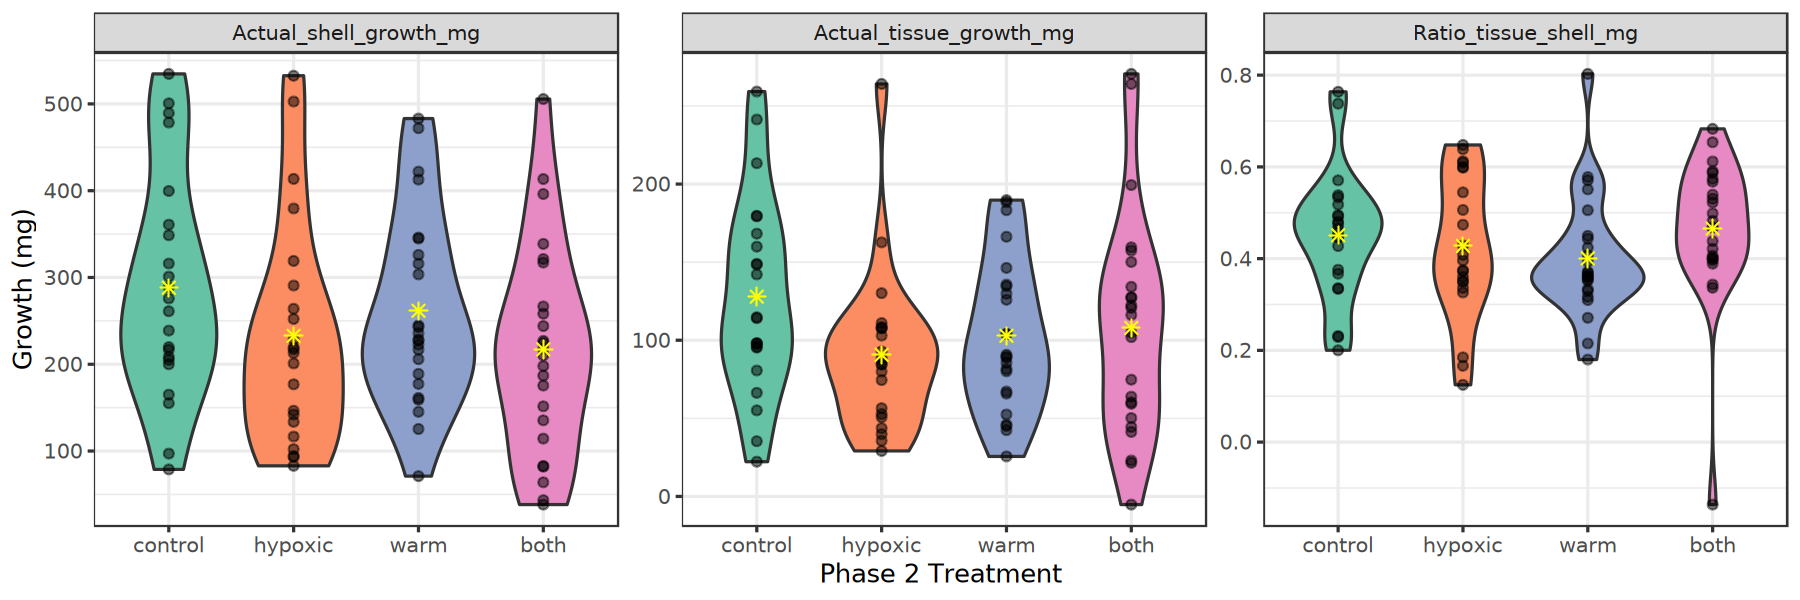

In [194]:
options(repr.plot.height = 5, repr.plot.width = 15)

p2.data$Phase2_treatment <- factor(p2.data$Phase2_treatment, levels = c('control', 'hypoxic', 'warm', 'both'))

ggplot(p2.data, aes(x = Phase2_treatment, y = Growth_mg, fill = Phase2_treatment)) +
geom_violin() +
geom_point(alpha=0.5) +
stat_summary(
    fun = "mean", 
    geom = "point", 
    shape = 8,      # asterick shape
    size = 3,        # Size of the point
    color = "yellow"  # Outline color
  ) +
scale_fill_brewer(palette = 'Set2') +
guides(fill = 'none') +
facet_wrap(~Growth_metric, scales = 'free') +
theme_bw(base_size = 15) +
labs(x = 'Phase 2 Treatment',
    y = 'Growth (mg)')

### Shell Growth

#### A. only looking at Phase 2 treatment

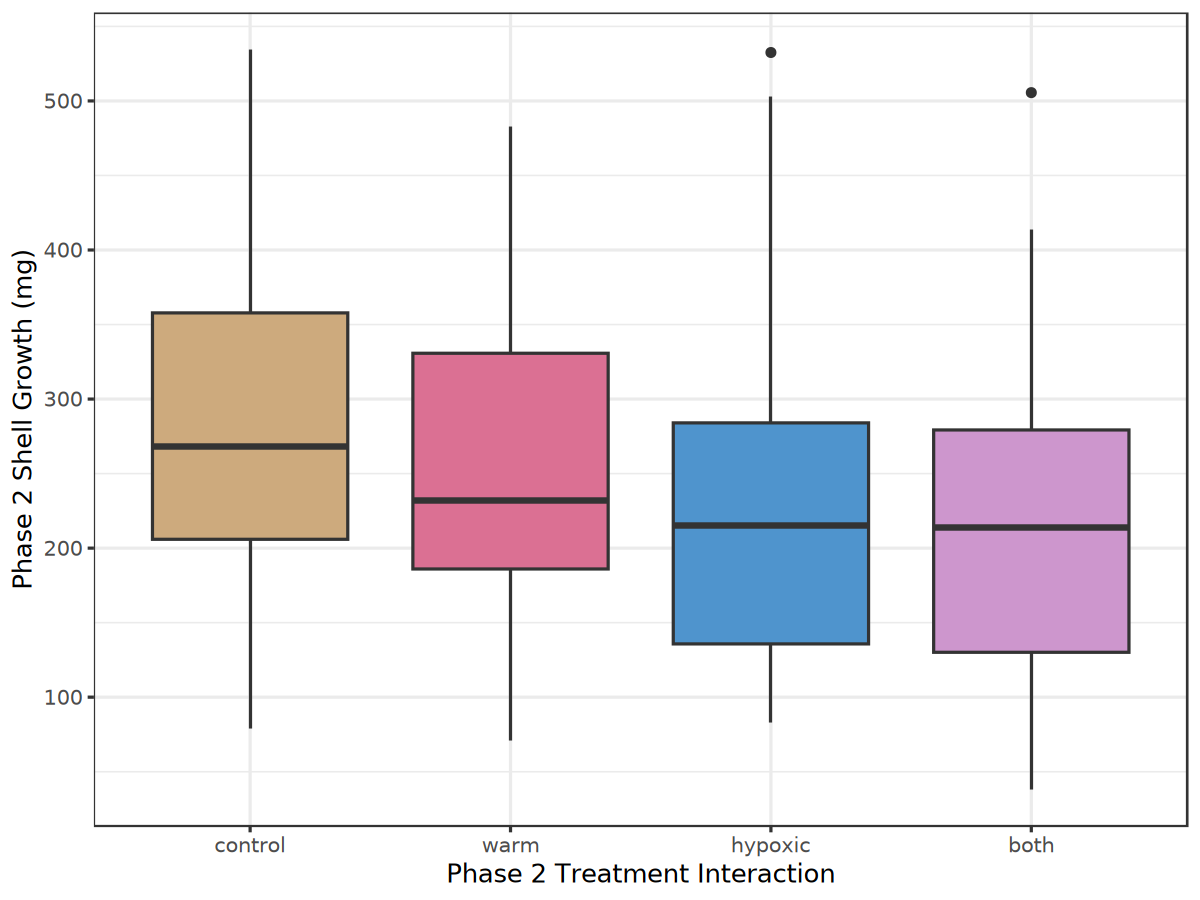

In [65]:
options(repr.plot.height = 7.5, repr.plot.width = 10)

s_phase2 <- ggplot(data, aes(x = Phase2_treatment, y = Actual_shell_growth_mg, fill = Phase2_treatment)) +
geom_boxplot() +
scale_fill_manual(values = c("hypoxic" = "steelblue3", "warm" = "palevioletred", "control" = "burlywood3", "both" = "plum3")) +
 guides(fill = "none") + # Remove legend for color
labs(y = 'Phase 2 Shell Growth (mg)',
     x = 'Phase 2 Treatment Interaction') +
theme_bw(base_size = 15)

s_phase2

In [66]:
summary(aov(Actual_shell_growth_mg ~ Phase2_treatment, data = data))

                 Df  Sum Sq Mean Sq F value Pr(>F)
Phase2_treatment  3   67626   22542   1.502   0.22
Residuals        88 1320862   15010               

average growth decreases with treatments but not significantly

#### B. Phase 1 and 2 treatment

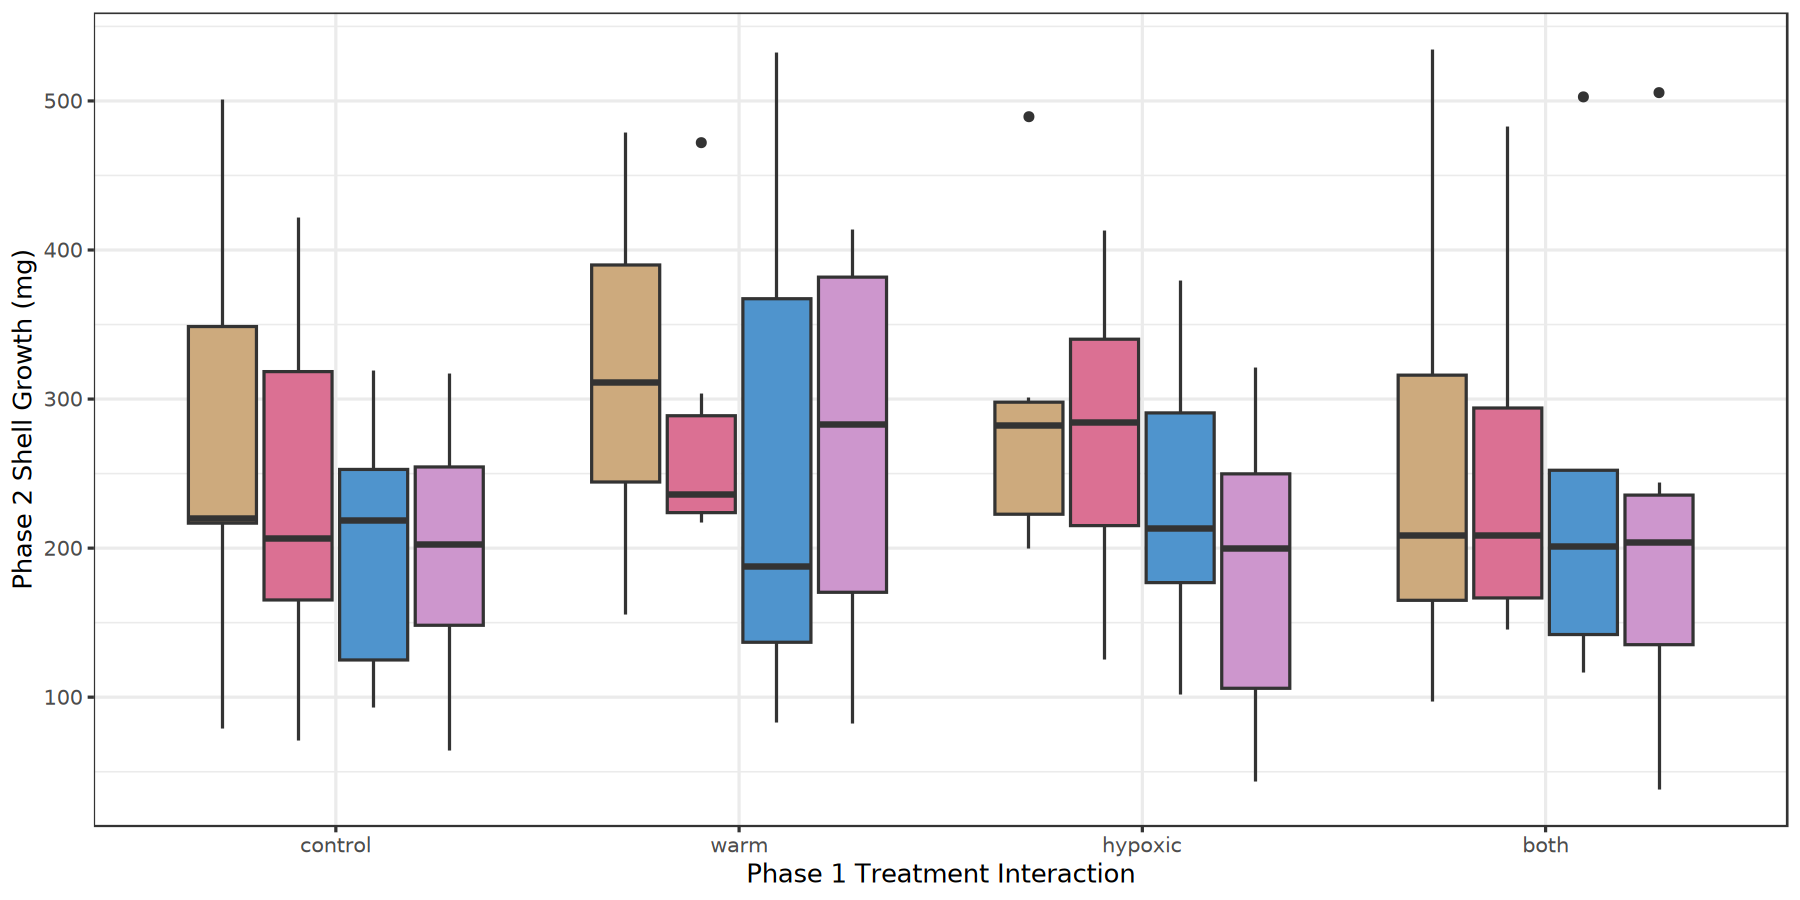

In [67]:
options(repr.plot.height = 7.5, repr.plot.width = 15)

s_all <- ggplot(data, aes(x = Phase1_treatment, y = Actual_shell_growth_mg, fill = Phase2_treatment)) +
geom_boxplot() +
scale_fill_manual(values = c("hypoxic" = "steelblue3", "warm" = "palevioletred", "control" = "burlywood3", "both" = "plum3")) +
 guides(fill = "none") + # Remove legend for color
labs(y = 'Phase 2 Shell Growth (mg)',
     x = 'Phase 1 Treatment Interaction') +
theme_bw(base_size = 15)

s_all

In [68]:
summary(aov(Actual_shell_growth_mg ~ Phase1_treatment + Phase2_treatment + Phase1_treatment:Phase2_treatment, data = data))

                                  Df  Sum Sq Mean Sq F value Pr(>F)
Phase1_treatment                   3   37503   12501   0.748  0.527
Phase2_treatment                   3   65692   21897   1.310  0.277
Phase1_treatment:Phase2_treatment  9   15340    1704   0.102  1.000
Residuals                         76 1269954   16710               

no significant differences of shell growth between treatments

#### C. Phase 2 temp

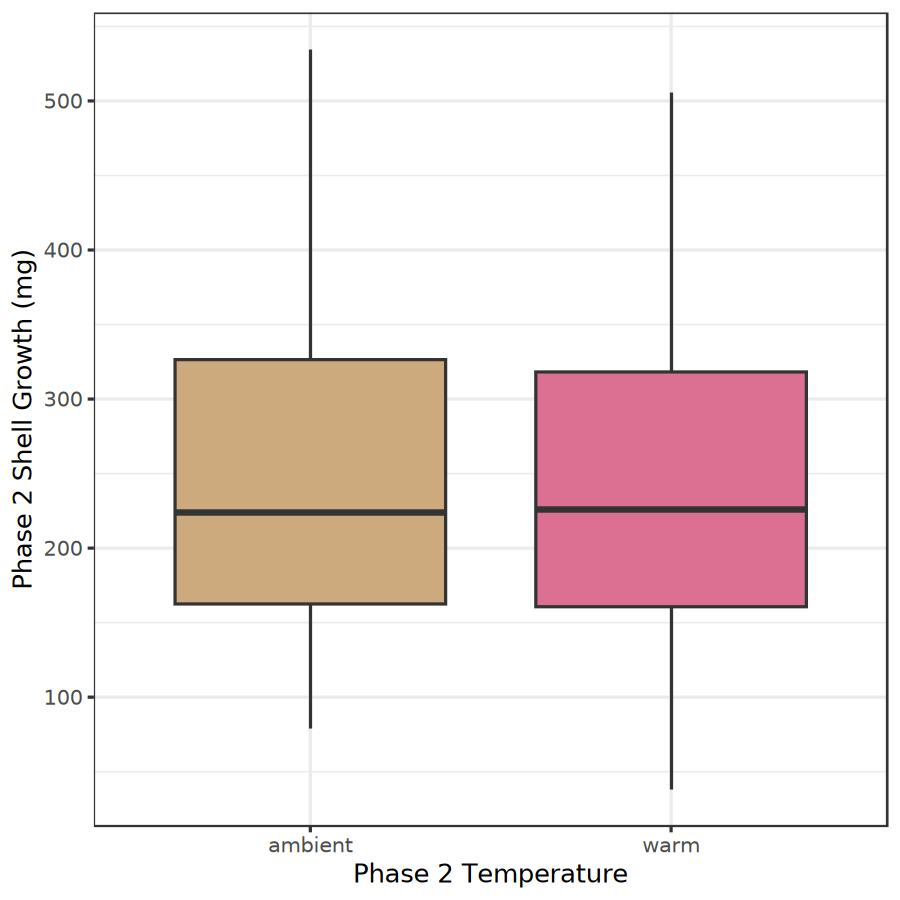

In [69]:
options(repr.plot.height = 7.5, repr.plot.width = 7.5)

s_p2temp <- ggplot(data, aes(x = Phase2_temp, y = Actual_shell_growth_mg, fill = Phase2_temp)) +
geom_boxplot() +
scale_fill_manual(values = c("warm" = "palevioletred", "ambient" = "burlywood3")) +
 guides(fill = "none") + # Remove legend for color
labs(y = 'Phase 2 Shell Growth (mg)',
     x = 'Phase 2 Temperature') +
theme_bw(base_size = 15)

s_p2temp

In [70]:
summary(aov(Actual_shell_growth_mg ~ Phase2_temp, data = data))

            Df  Sum Sq Mean Sq F value Pr(>F)
Phase2_temp  1   10198   10198   0.666  0.417
Residuals   90 1378290   15314               

no significant differences in shell growth between phase 2 temp treatments

#### D. Phase 2 DO

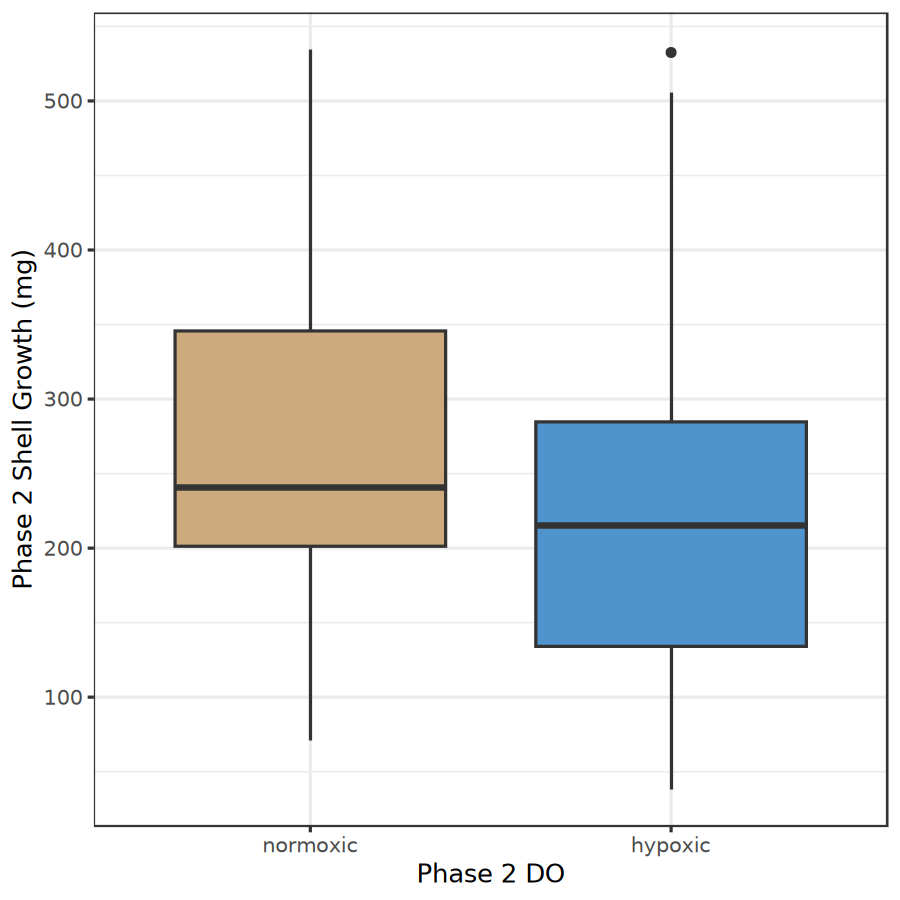

In [71]:
options(repr.plot.height = 7.5, repr.plot.width = 7.5)

s_p2do <- ggplot(data, aes(x = Phase2_DO, y = Actual_shell_growth_mg, fill = Phase2_DO)) +
geom_boxplot() +
scale_fill_manual(values = c("hypoxic" = "steelblue3", "normoxic" = "burlywood3")) +
 guides(fill = "none") + # Remove legend for color
labs(y = 'Phase 2 Shell Growth (mg)',
     x = 'Phase 2 DO') +
theme_bw(base_size = 15)

s_p2do

In [72]:
summary(aov(Actual_shell_growth_mg ~ Phase2_DO, data = data))

            Df  Sum Sq Mean Sq F value Pr(>F)  
Phase2_DO    1   56737   56737   3.834 0.0533 .
Residuals   90 1331751   14797                 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

trending significant (?? lol) difference between shell growth between Phase 2 DO treatments

### Tissue Growth

#### A. only looking at Phase 2 treatment

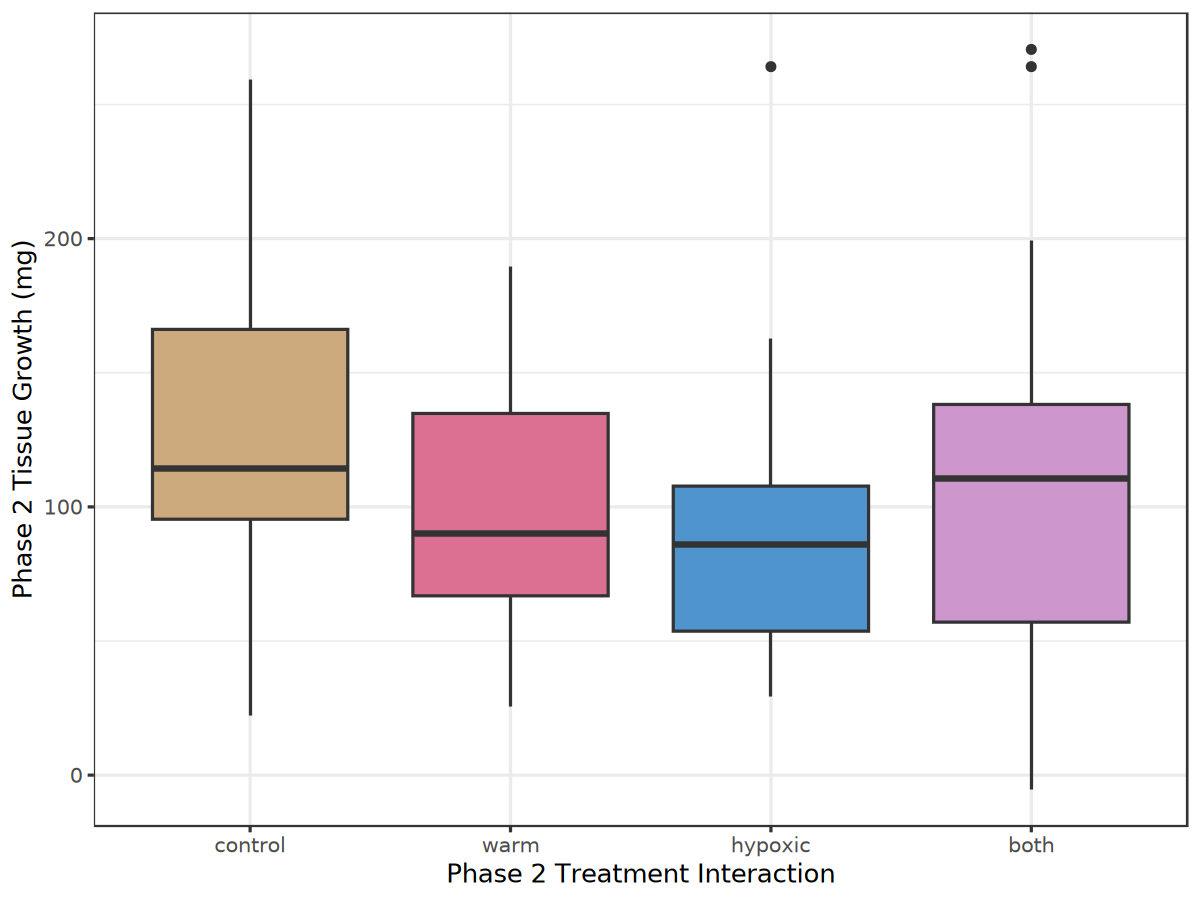

In [104]:
options(repr.plot.height = 7.5, repr.plot.width = 10)

t_phase2 <- ggplot(data, aes(x = Phase2_treatment, y = Actual_tissue_growth_mg, fill = Phase2_treatment)) +
#geom_point(alpha = 0.5) +
geom_boxplot() +
scale_fill_manual(values = c("hypoxic" = "steelblue3", "warm" = "palevioletred", "control" = "burlywood3", "both" = "plum3")) +
 guides(fill = "none") + # Remove legend for color
labs(y = 'Phase 2 Tissue Growth (mg)',
     x = 'Phase 2 Treatment Interaction') +
theme_bw(base_size = 15)

t_phase2

In [105]:
summary(aov(Actual_tissue_growth_mg ~ Phase2_treatment, data = data))

                 Df Sum Sq Mean Sq F value Pr(>F)
Phase2_treatment  3  15896    5299   1.524  0.214
Residuals        88 305961    3477               

average growth decreases with treatments but not significantly (and only for single stressors)

#### B. Phase 1 and 2 treatment

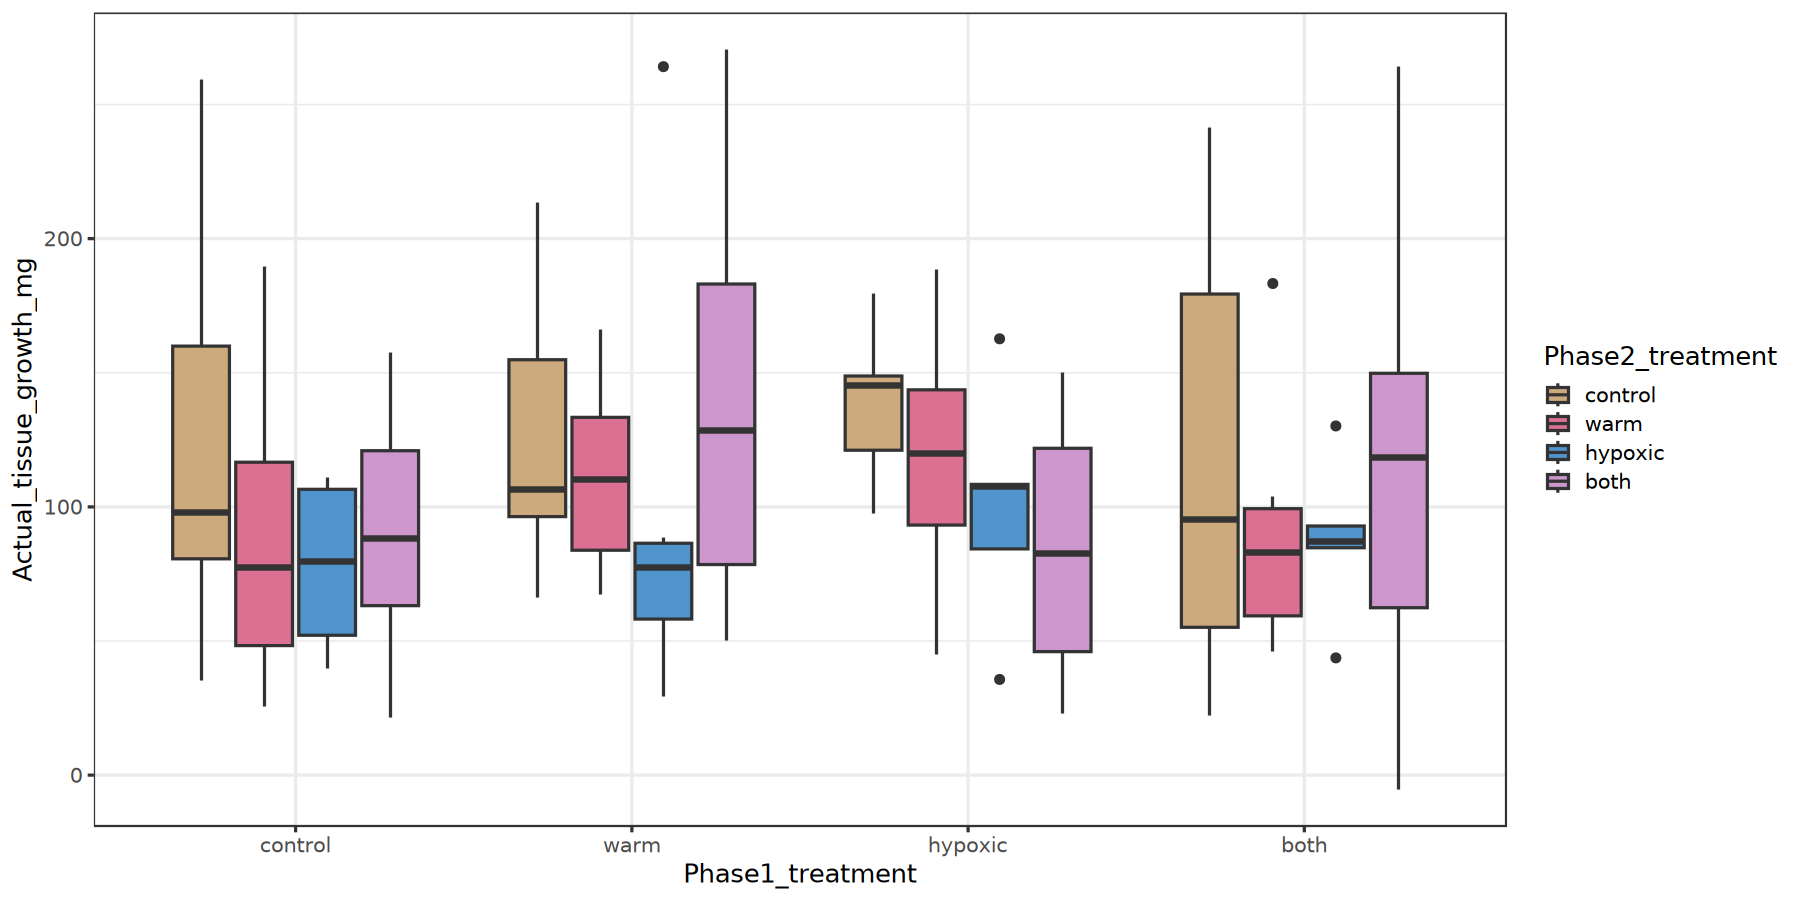

In [106]:
options(repr.plot.height = 7.5, repr.plot.width = 15)

t_all <- ggplot(data, aes(x = Phase1_treatment, y = Actual_tissue_growth_mg, fill = Phase2_treatment)) +
geom_boxplot() +
scale_fill_manual(values = c("hypoxic" = "steelblue3", "warm" = "palevioletred", "control" = "burlywood3", "both" = "plum3")) +
theme_bw(base_size = 15)

t_all

In [107]:
summary(aov(Actual_tissue_growth_mg ~ Phase1_treatment + Phase2_treatment + Phase1_treatment:Phase2_treatment, data = data))

                                  Df Sum Sq Mean Sq F value Pr(>F)
Phase1_treatment                   3   7369    2456   0.649  0.586
Phase2_treatment                   3  15284    5095   1.346  0.266
Phase1_treatment:Phase2_treatment  9  11538    1282   0.339  0.959
Residuals                         76 287666    3785               

no significant differences of shell growth between treatments

#### C. Phase 2 temp

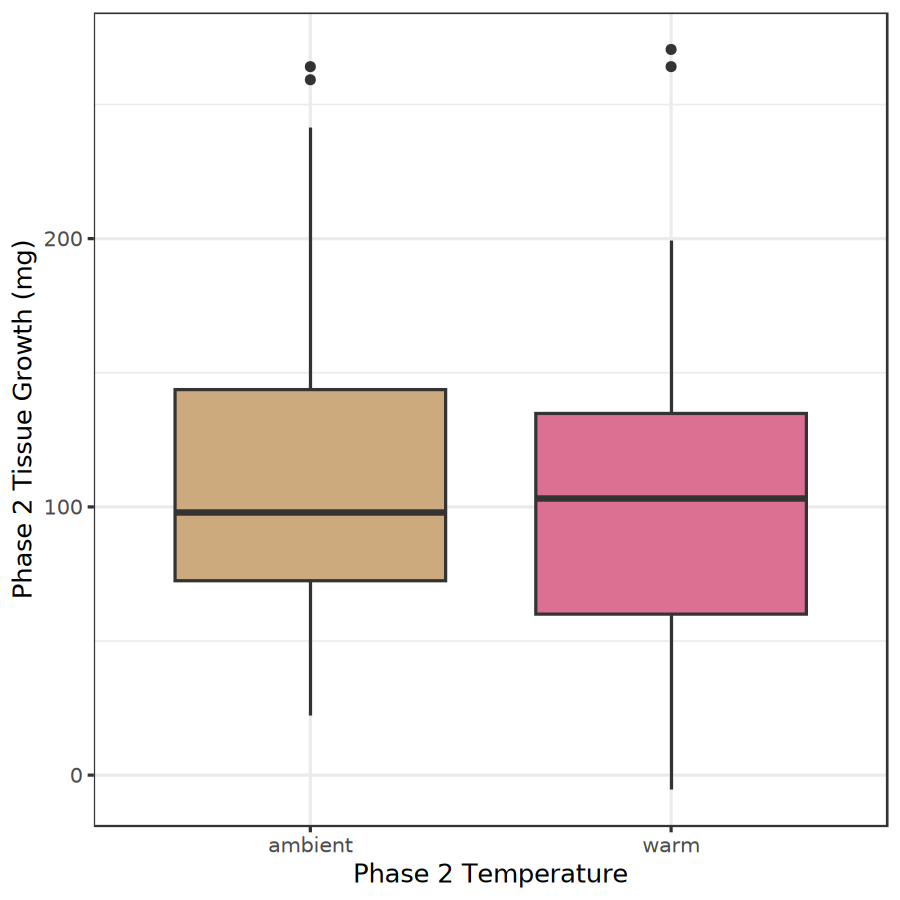

In [108]:
options(repr.plot.height = 7.5, repr.plot.width = 7.5)

t_p2temp <- ggplot(data, aes(x = Phase2_temp, y = Actual_tissue_growth_mg, fill = Phase2_temp)) +
geom_boxplot() +
scale_fill_manual(values = c("warm" = "palevioletred", "ambient" = "burlywood3")) +
 guides(fill = "none") + # Remove legend for color
labs(y = 'Phase 2 Tissue Growth (mg)',
     x = 'Phase 2 Temperature') +
theme_bw(base_size = 15)

t_p2temp

In [109]:
summary(aov(Actual_tissue_growth_mg ~ Phase2_temp, data = data))

            Df Sum Sq Mean Sq F value Pr(>F)
Phase2_temp  1    350     350   0.098  0.755
Residuals   90 321507    3572               

no significant differences in tissue growth between phase 2 temp treatments

#### D. Phase 2 DO

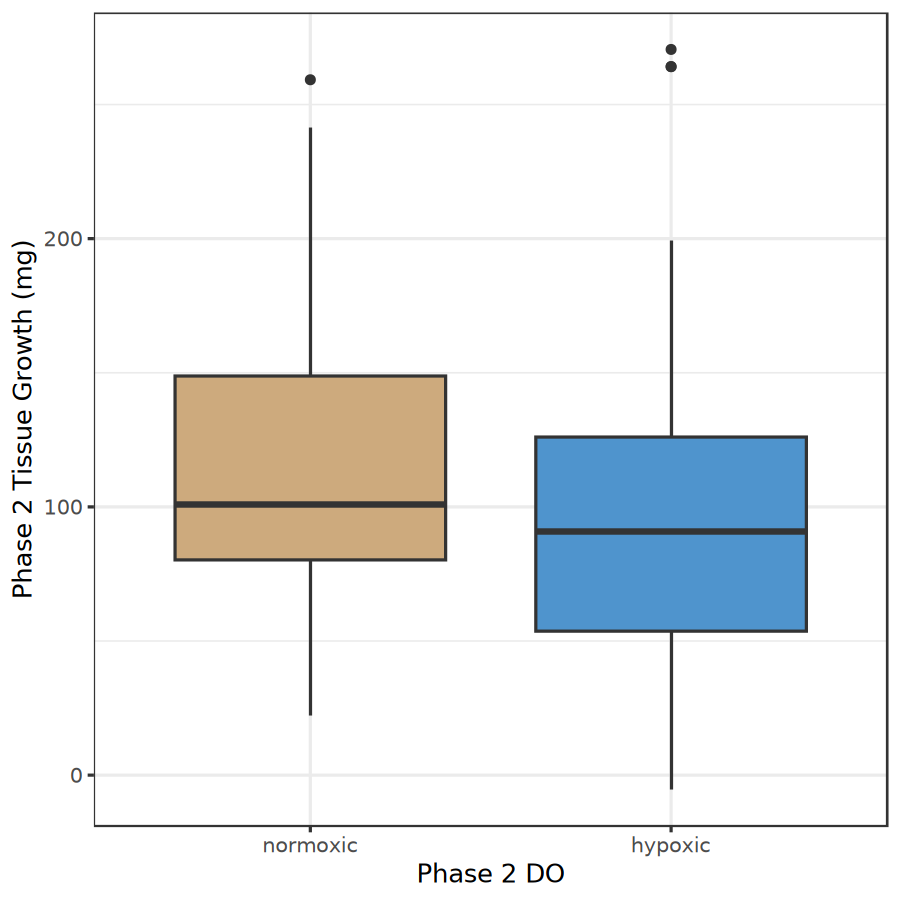

In [110]:
options(repr.plot.height = 7.5, repr.plot.width = 7.5)

t_p2do <- ggplot(data, aes(x = Phase2_DO, y = Actual_tissue_growth_mg, fill = Phase2_DO)) +
geom_boxplot() +
scale_fill_manual(values = c("hypoxic" = "steelblue3", "normoxic" = "burlywood3")) +
  guides(fill = "none") + # Remove legend for color
labs(y = 'Phase 2 Tissue Growth (mg)',
     x = 'Phase 2 DO') +
theme_bw(base_size = 15)

t_p2do

In [111]:
summary(aov(Actual_tissue_growth_mg ~ Phase2_DO, data = data))

            Df Sum Sq Mean Sq F value Pr(>F)
Phase2_DO    1   5296    5296   1.506  0.223
Residuals   90 316561    3517               

no significant difference in tissue growth between phase 2 DO treatments

make into bar plots instead of boxplots where the bar is the mean

### Isolate phase 2 treatment plots

In [158]:
plot_dat <- data %>%
  pivot_longer(
    cols = c(Actual_shell_growth_mg, Actual_tissue_growth_mg, Ratio_tissue_shell_mg),
    names_to = "Response",
    values_to = "Growth"
  )

phase_dat <- plot_dat %>%
  mutate(Predictor = "Phase",
         x = Phase2_treatment)

temp_dat <- plot_dat %>%
  mutate(Predictor = "Temperature",
         x = Phase2_temp)

do_dat <- plot_dat %>%
  mutate(Predictor = "DO",
         x = Phase2_DO)

facet_dat <- bind_rows(phase_dat, temp_dat, do_dat)

# set factor
facet_dat$Predictor <- factor(facet_dat$Predictor, levels = c('Phase','Temperature','DO'))


head(facet_dat)

X,Sample,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,combo_trtmt,Module,Eigengene,Response,Growth,Predictor,x
<int>,<chr>,<fct>,<fct>,<fct>,<int>,<fct>,<fct>,<fct>,<int>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<fct>,<fct>
1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both_both,MEgrey60,0.07434743,Actual_shell_growth_mg,210.2755200,Phase,both
1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both_both,MEgrey60,0.07434743,Actual_tissue_growth_mg,120.7244800,Phase,both
1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both_both,MEgrey60,0.07434743,Ratio_tissue_shell_mg,0.5741252,Phase,both
2,B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both_warm,MEgrey60,0.07549295,Actual_shell_growth_mg,315.8883000,Phase,warm
2,B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both_warm,MEgrey60,0.07549295,Actual_tissue_growth_mg,85.6117000,Phase,warm
2,B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both_warm,MEgrey60,0.07549295,Ratio_tissue_shell_mg,0.2710189,Phase,warm


In [159]:
summary_stats <- facet_dat %>%
  group_by(Predictor, x, Response) %>%
  mutate(
    mean_growth = mean(Growth, na.rm = TRUE),
    se_growth = std.error(Growth, na.rm = TRUE)) %>%
distinct(Response, Predictor, x, .keep_all = TRUE)

head(summary_stats)
     

X,Sample,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,combo_trtmt,Module,Eigengene,Response,Growth,Predictor,x,mean_growth,se_growth
<int>,<chr>,<fct>,<fct>,<fct>,<int>,<fct>,<fct>,<fct>,<int>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<fct>,<fct>,<dbl>,<dbl>
1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both_both,MEgrey60,0.07434743,Actual_shell_growth_mg,210.2755200,Phase,both,217.1962975,24.85370539
1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both_both,MEgrey60,0.07434743,Actual_tissue_growth_mg,120.7244800,Phase,both,107.9078692,14.43237840
1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both_both,MEgrey60,0.07434743,Ratio_tissue_shell_mg,0.5741252,Phase,both,0.4655402,0.03268678
2,B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both_warm,MEgrey60,0.07549295,Actual_shell_growth_mg,315.8883000,Phase,warm,261.6172650,22.37629164
2,B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both_warm,MEgrey60,0.07549295,Actual_tissue_growth_mg,85.6117000,Phase,warm,102.8702350,9.86674954
2,B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both_warm,MEgrey60,0.07549295,Ratio_tissue_shell_mg,0.2710189,Phase,warm,0.4004970,0.02679368


In [160]:
sumStats.16 <- facet_dat %>%
  group_by(combo_trtmt, Response) %>%
  mutate(
    mean_growth = mean(Growth, na.rm = TRUE),
    se_growth = std.error(Growth, na.rm = TRUE)) %>%
distinct(Response, combo_trtmt, .keep_all = TRUE)

head(sumStats.16)

X,Sample,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,combo_trtmt,Module,Eigengene,Response,Growth,Predictor,x,mean_growth,se_growth
<int>,<chr>,<fct>,<fct>,<fct>,<int>,<fct>,<fct>,<fct>,<int>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<fct>,<fct>,<dbl>,<dbl>
1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both_both,MEgrey60,0.07434743,Actual_shell_growth_mg,210.2755200,Phase,both,218.4036400,35.26852043
1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both_both,MEgrey60,0.07434743,Actual_tissue_growth_mg,120.7244800,Phase,both,116.6296933,20.68932043
1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both_both,MEgrey60,0.07434743,Ratio_tissue_shell_mg,0.5741252,Phase,both,0.4316765,0.06464093
2,B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both_warm,MEgrey60,0.07549295,Actual_shell_growth_mg,315.8883000,Phase,warm,253.4231700,28.36180062
2,B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both_warm,MEgrey60,0.07549295,Actual_tissue_growth_mg,85.6117000,Phase,warm,91.8934967,10.99621470
2,B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both_warm,MEgrey60,0.07549295,Ratio_tissue_shell_mg,0.2710189,Phase,warm,0.3932268,0.04698201


In [161]:
phase2_inter <- summary_stats %>%
filter(Predictor == 'Phase')
phase2_inter

# separate into two groups
p2_shell <- phase2_inter %>% filter(Response == 'Actual_shell_growth_mg')
p2_tissue <- phase2_inter %>% filter(Response == 'Actual_tissue_growth_mg')
p2_ts <- phase2_inter %>% filter(Response == 'Ratio_tissue_shell_mg')

X,Sample,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,combo_trtmt,Module,Eigengene,Response,Growth,Predictor,x,mean_growth,se_growth
<int>,<chr>,<fct>,<fct>,<fct>,<int>,<fct>,<fct>,<fct>,<int>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<fct>,<fct>,<dbl>,<dbl>
1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both_both,MEgrey60,0.07434743,Actual_shell_growth_mg,210.2755200,Phase,both,217.1962975,24.85370539
1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both_both,MEgrey60,0.07434743,Actual_tissue_growth_mg,120.7244800,Phase,both,107.9078692,14.43237840
1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both_both,MEgrey60,0.07434743,Ratio_tissue_shell_mg,0.5741252,Phase,both,0.4655402,0.03268678
2,B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both_warm,MEgrey60,0.07549295,Actual_shell_growth_mg,315.8883000,Phase,warm,261.6172650,22.37629164
2,B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both_warm,MEgrey60,0.07549295,Actual_tissue_growth_mg,85.6117000,Phase,warm,102.8702350,9.86674954
2,B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both_warm,MEgrey60,0.07549295,Ratio_tissue_shell_mg,0.2710189,Phase,warm,0.4004970,0.02679368
4,B2_C4_O40,both,warm,hypoxic,2,control,ambient,normoxic,4,both_control,MEgrey60,0.04819095,Actual_shell_growth_mg,164.9902800,Phase,control,288.1788000,27.61175412
4,B2_C4_O40,both,warm,hypoxic,2,control,ambient,normoxic,4,both_control,MEgrey60,0.04819095,Actual_tissue_growth_mg,55.1097200,Phase,control,127.9075636,13.37741694
4,B2_C4_O40,both,warm,hypoxic,2,control,ambient,normoxic,4,both_control,MEgrey60,0.04819095,Ratio_tissue_shell_mg,0.3340180,Phase,control,0.4510664,0.03012957


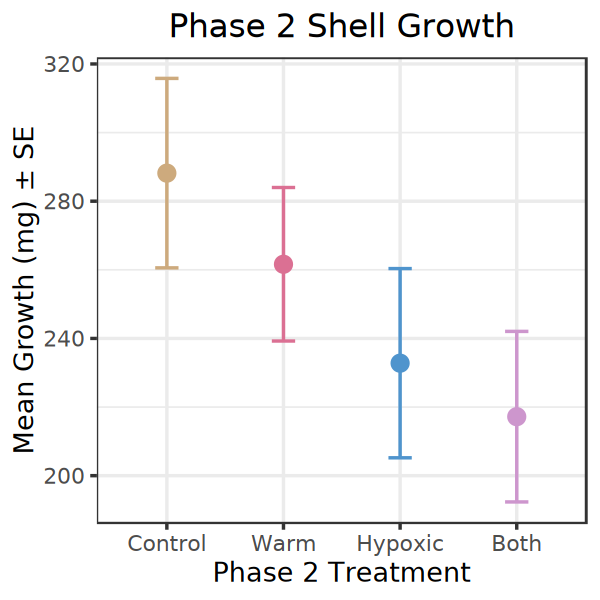

In [162]:
options(repr.plot.width = 5, repr.plot.height = 5)

shell <- ggplot(p2_shell, aes(x = x, y = mean_growth, color = x)) +
# Plot means as points
geom_point(size = 4, position = position_dodge(0.9)) + 
 # Error bars for SD
geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
              width = 0.2, position = position_dodge(0.9)) +
#scale_y_continuous(position = "right") +   # move y-axis to right 
scale_color_manual(values = c("hypoxic" = "steelblue3", "warm" = "palevioletred", "control" = "burlywood3", "both" = "plum3")) +
scale_x_discrete(labels = stringr::str_to_title) +
guides(fill = 'none') +
labs(x = 'Phase 2 Treatment',
    y = 'Mean Growth (mg) ± SE',
    title = 'Phase 2 Shell Growth') +
theme_bw(base_size = 16) +
theme(legend.position = "none",
      plot.title = element_text(hjust = 0.5)
) 

shell

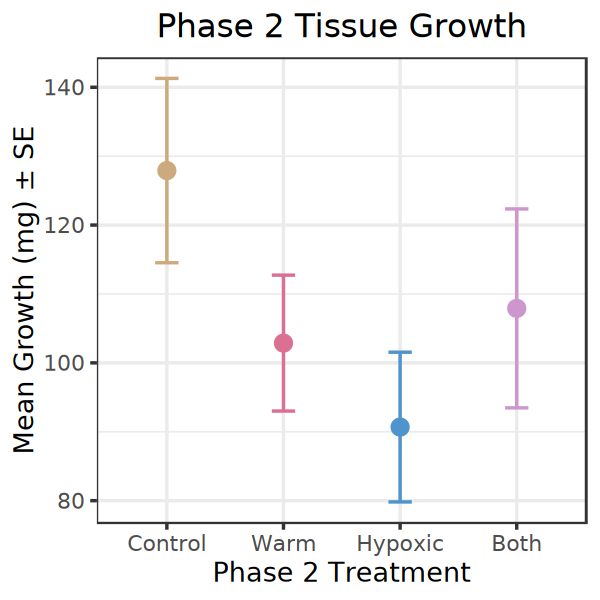

In [163]:
options(repr.plot.width = 5, repr.plot.height = 5)

tissue <- ggplot(p2_tissue, aes(x = x, y = mean_growth, color = x)) +
# Plot means as points
geom_point(size = 4, position = position_dodge(0.9)) + 
 # Error bars for SD
geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
              width = 0.2, position = position_dodge(0.9)) +
#scale_y_continuous(position = "right") +   # move y-axis to right 
scale_color_manual(values = c("hypoxic" = "steelblue3", "warm" = "palevioletred", "control" = "burlywood3", "both" = "plum3")) +
scale_x_discrete(labels = stringr::str_to_title) +
guides(fill = 'none') +
labs(x = 'Phase 2 Treatment',
    y = 'Mean Growth (mg) ± SE',
    title = 'Phase 2 Tissue Growth') +
theme_bw(base_size = 16) +
theme(legend.position = "none",
      plot.title = element_text(hjust = 0.5)
) 

tissue

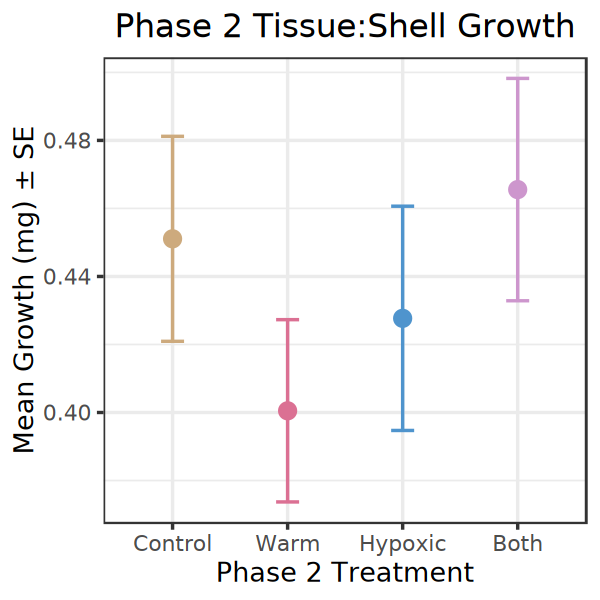

In [164]:
options(repr.plot.width = 5, repr.plot.height = 5)

t_s <- ggplot(p2_ts, aes(x = x, y = mean_growth, color = x)) +
# Plot means as points
geom_point(size = 4, position = position_dodge(0.9)) + 
 # Error bars for SD
geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
              width = 0.2, position = position_dodge(0.9)) +
#scale_y_continuous(position = "right") +   # move y-axis to right 
scale_color_manual(values = c("hypoxic" = "steelblue3", "warm" = "palevioletred", "control" = "burlywood3", "both" = "plum3")) +
scale_x_discrete(labels = stringr::str_to_title) +
guides(fill = 'none') +
labs(x = 'Phase 2 Treatment',
    y = 'Mean Growth (mg) ± SE',
    title = 'Phase 2 Tissue:Shell Growth') +
theme_bw(base_size = 16) +
theme(legend.position = "none",
      plot.title = element_text(hjust = 0.5)
) 

t_s

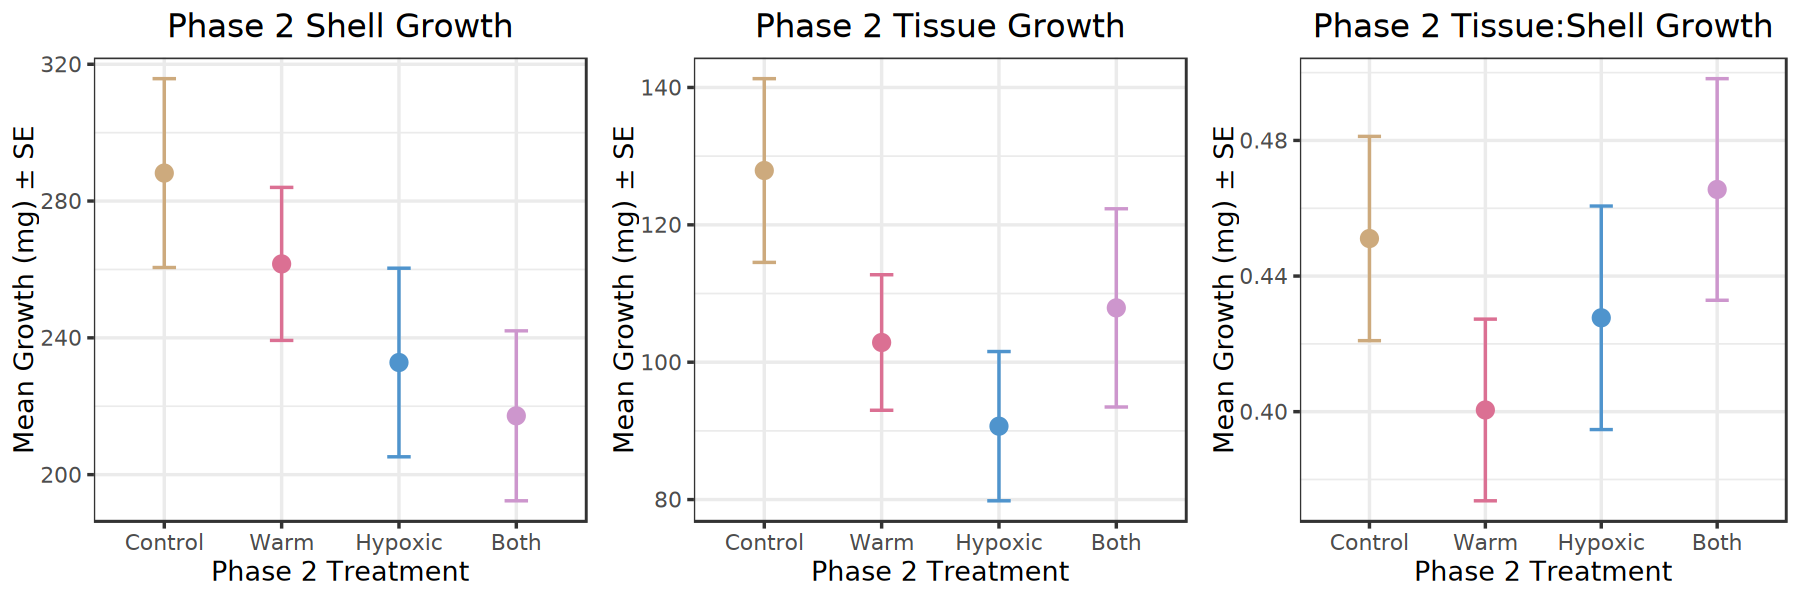

In [165]:
options(repr.plot.height = 5, repr.plot.width = 15)

plot1 <- plot_grid(shell, tissue, t_s, nrow = 1)
plot1

In [166]:
ggsave(
  filename = '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/growth/plots/phase2_growth.png', 
  plot = plot1, 
  width = 15,    
  height = 5,     
  units = "in", 
  dpi = 300         # High resolution for clarity
)

### Stat testing

In [167]:
m1 <- aov(Actual_tissue_growth_mg ~ Phase1_DO*Phase1_temp*Phase2_temp*Phase2_DO, data = data)
summary(m1)

                                            Df Sum Sq Mean Sq F value Pr(>F)
Phase1_DO                                    1      0       0   0.000  0.994
Phase1_temp                                  1   1835    1835   0.485  0.488
Phase2_temp                                  1    352     352   0.093  0.761
Phase2_DO                                    1   5293    5293   1.398  0.241
Phase1_DO:Phase1_temp                        1   5245    5245   1.386  0.243
Phase1_DO:Phase2_temp                        1    681     681   0.180  0.673
Phase1_temp:Phase2_temp                      1   2849    2849   0.753  0.388
Phase1_DO:Phase2_DO                          1    340     340   0.090  0.765
Phase1_temp:Phase2_DO                        1   4842    4842   1.279  0.262
Phase2_temp:Phase2_DO                        1   9920    9920   2.621  0.110
Phase1_DO:Phase1_temp:Phase2_temp            1     89      89   0.024  0.878
Phase1_DO:Phase1_temp:Phase2_DO              1    161     161   0.043  0.837

In [168]:
m1 <- aov(Actual_shell_growth_mg ~ Phase1_DO*Phase1_temp*Phase2_temp*Phase2_DO, data = data)
summary(m1)

                                            Df  Sum Sq Mean Sq F value Pr(>F)  
Phase1_DO                                    1    1324    1324   0.079 0.7791  
Phase1_temp                                  1   16406   16406   0.982 0.3249  
Phase2_temp                                  1   10050   10050   0.601 0.4404  
Phase2_DO                                    1   57089   57089   3.416 0.0684 .
Phase1_DO:Phase1_temp                        1   17745   17745   1.062 0.3060  
Phase1_DO:Phase2_temp                        1     619     619   0.037 0.8479  
Phase1_temp:Phase2_temp                      1     771     771   0.046 0.8305  
Phase1_DO:Phase2_DO                          1     428     428   0.026 0.8733  
Phase1_temp:Phase2_DO                        1    6158    6158   0.369 0.5456  
Phase2_temp:Phase2_DO                        1     580     580   0.035 0.8527  
Phase1_DO:Phase1_temp:Phase2_temp            1      44      44   0.003 0.9591  
Phase1_DO:Phase1_temp:Phase2_DO         

In [169]:
m1 <- aov(Ratio_tissue_shell_mg ~ Phase1_DO*Phase1_temp*Phase2_temp*Phase2_DO, data = data)
summary(m1)

                                            Df Sum Sq Mean Sq F value Pr(>F)
Phase1_DO                                    1 0.0002 0.00021   0.009  0.926
Phase1_temp                                  1 0.0056 0.00557   0.230  0.633
Phase2_temp                                  1 0.0009 0.00095   0.039  0.844
Phase2_DO                                    1 0.0120 0.01198   0.494  0.484
Phase1_DO:Phase1_temp                        1 0.0094 0.00943   0.389  0.535
Phase1_DO:Phase2_temp                        1 0.0021 0.00209   0.086  0.770
Phase1_temp:Phase2_temp                      1 0.0154 0.01542   0.636  0.428
Phase1_DO:Phase2_DO                          1 0.0043 0.00427   0.176  0.676
Phase1_temp:Phase2_DO                        1 0.0068 0.00677   0.279  0.599
Phase2_temp:Phase2_DO                        1 0.0441 0.04412   1.821  0.181
Phase1_DO:Phase1_temp:Phase2_temp            1 0.0156 0.01558   0.643  0.425
Phase1_DO:Phase1_temp:Phase2_DO              1 0.0003 0.00031   0.013  0.910

### all 16 treatment combos

#### shell

In [170]:
head(sumStats.16)

X,Sample,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,combo_trtmt,Module,Eigengene,Response,Growth,Predictor,x,mean_growth,se_growth
<int>,<chr>,<fct>,<fct>,<fct>,<int>,<fct>,<fct>,<fct>,<int>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<fct>,<fct>,<dbl>,<dbl>
1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both_both,MEgrey60,0.07434743,Actual_shell_growth_mg,210.2755200,Phase,both,218.4036400,35.26852043
1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both_both,MEgrey60,0.07434743,Actual_tissue_growth_mg,120.7244800,Phase,both,116.6296933,20.68932043
1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both_both,MEgrey60,0.07434743,Ratio_tissue_shell_mg,0.5741252,Phase,both,0.4316765,0.06464093
2,B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both_warm,MEgrey60,0.07549295,Actual_shell_growth_mg,315.8883000,Phase,warm,253.4231700,28.36180062
2,B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both_warm,MEgrey60,0.07549295,Actual_tissue_growth_mg,85.6117000,Phase,warm,91.8934967,10.99621470
2,B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both_warm,MEgrey60,0.07549295,Ratio_tissue_shell_mg,0.2710189,Phase,warm,0.3932268,0.04698201


In [171]:
shell16 <- sumStats.16 %>% filter(Response == 'Actual_shell_growth_mg')
tissue16 <- sumStats.16 %>% filter(Response == 'Actual_tissue_growth_mg')
ratio16 <- sumStats.16 %>% filter(Response == 'Ratio_tissue_shell_mg')

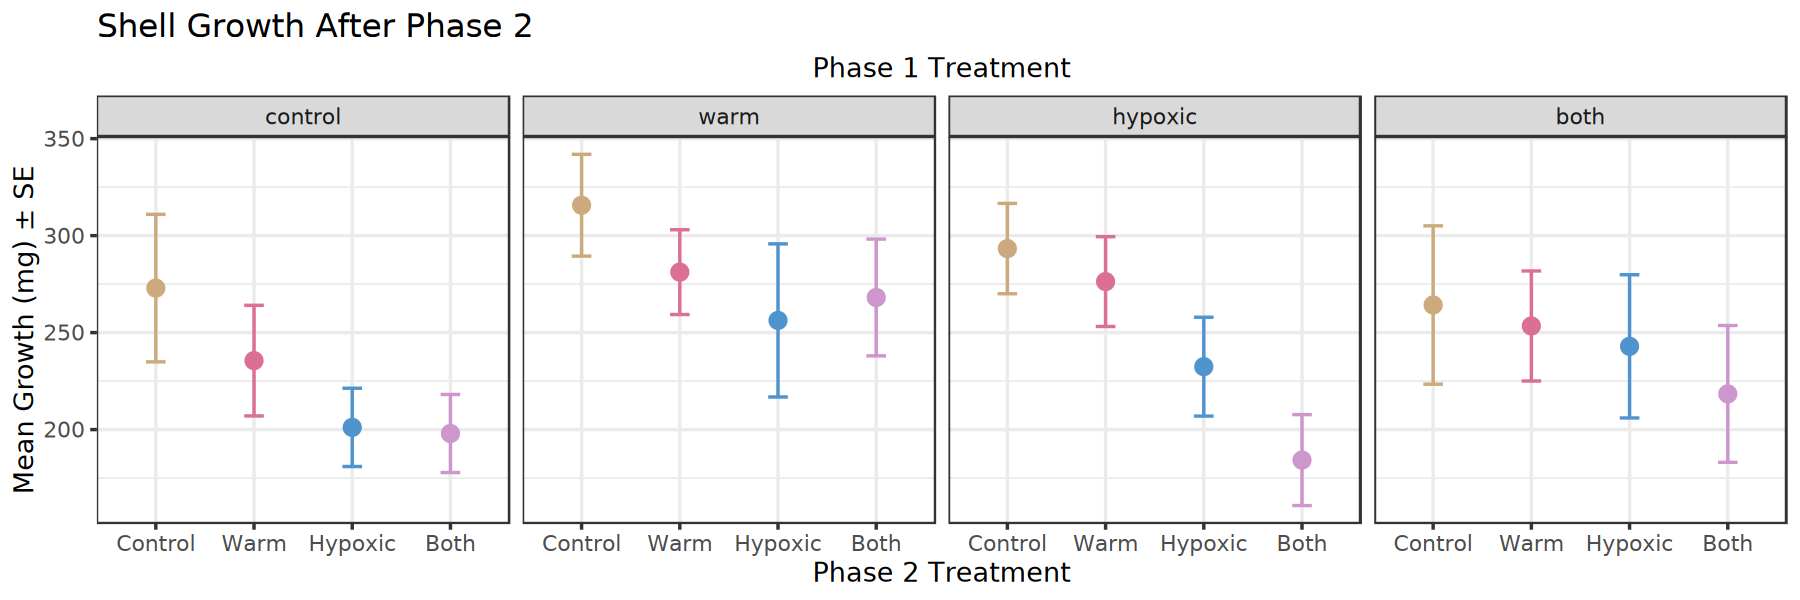

In [172]:
options(repr.plot.height = 5, repr.plot.width = 15)

shell16_plot <- ggplot(shell16, aes(x = Phase2_treatment, y = mean_growth, color = Phase2_treatment)) +
# Plot means as points
geom_point(size = 4, position = position_dodge(0.9)) + 
 # Error bars for SD
geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
              width = 0.2, position = position_dodge(0.9)) +
#scale_y_continuous(position = "right") +   # move y-axis to right 
facet_wrap(~Phase1_treatment, nrow = 1) +
scale_color_manual(values = c("hypoxic" = "steelblue3", "warm" = "palevioletred", "control" = "burlywood3", "both" = "plum3")) +
scale_x_discrete(labels = stringr::str_to_title) +
guides(fill = 'none') +
labs(x = 'Phase 2 Treatment',
    y = 'Mean Growth (mg) ± SE',
    title = 'Shell Growth After Phase 2',
    subtitle = 'Phase 1 Treatment') +
theme_bw(base_size = 16) +
theme(legend.position = "none",
      plot.subtitle = element_text(hjust = 0.5)
) 

shell16_plot

#### tissue

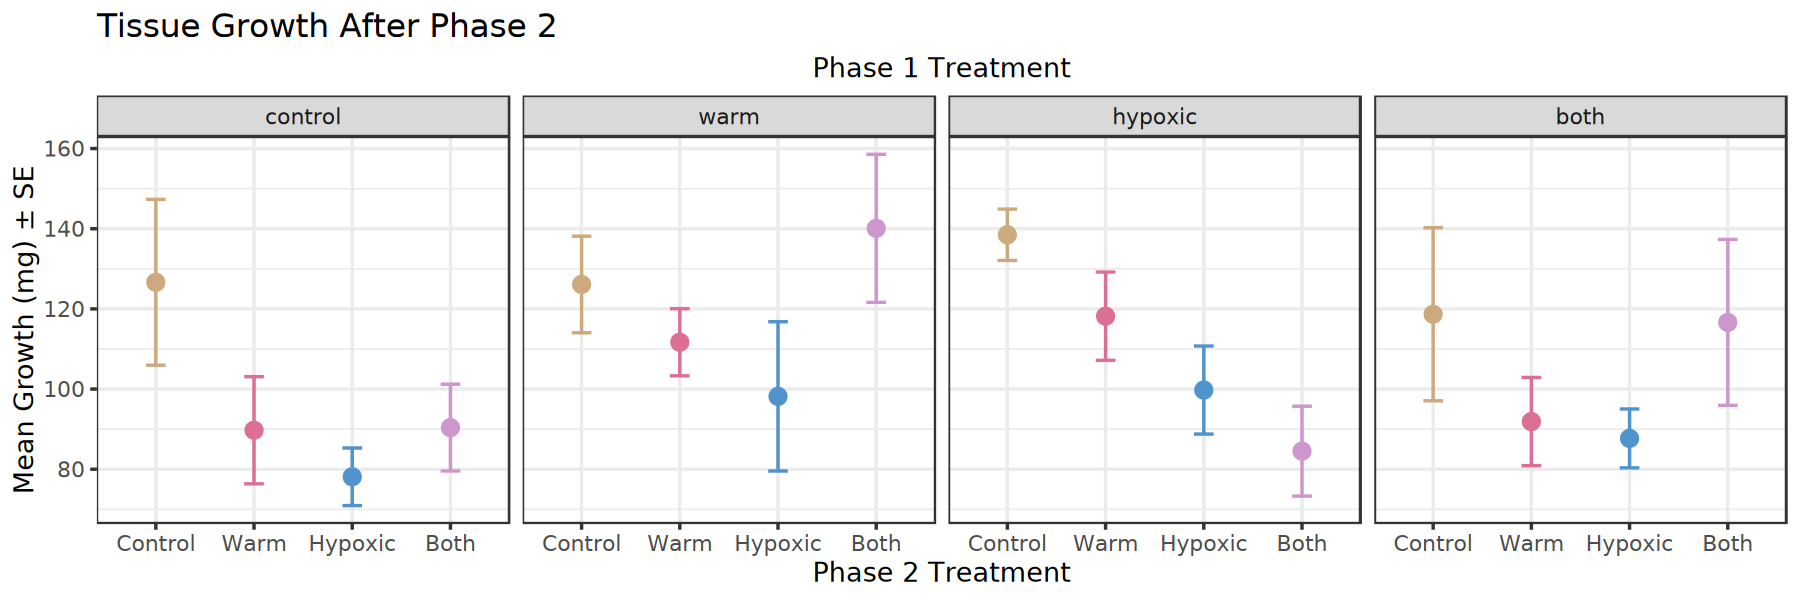

In [173]:
tissue16_plot <- ggplot(tissue16, aes(x = Phase2_treatment, y = mean_growth, color = Phase2_treatment)) +
# Plot means as points
geom_point(size = 4, position = position_dodge(0.9)) + 
 # Error bars for SD
geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
              width = 0.2, position = position_dodge(0.9)) +
#scale_y_continuous(position = "right") +   # move y-axis to right 
facet_wrap(~Phase1_treatment, nrow = 1) +
scale_color_manual(values = c("hypoxic" = "steelblue3", "warm" = "palevioletred", "control" = "burlywood3", "both" = "plum3")) +
scale_x_discrete(labels = stringr::str_to_title) +
guides(fill = 'none') +
labs(x = 'Phase 2 Treatment',
    y = 'Mean Growth (mg) ± SE',
    title = 'Tissue Growth After Phase 2',
    subtitle = 'Phase 1 Treatment') +
theme_bw(base_size = 16) +
theme(legend.position = "none",
      plot.subtitle = element_text(hjust = 0.5)
) 

tissue16_plot

#### ratio

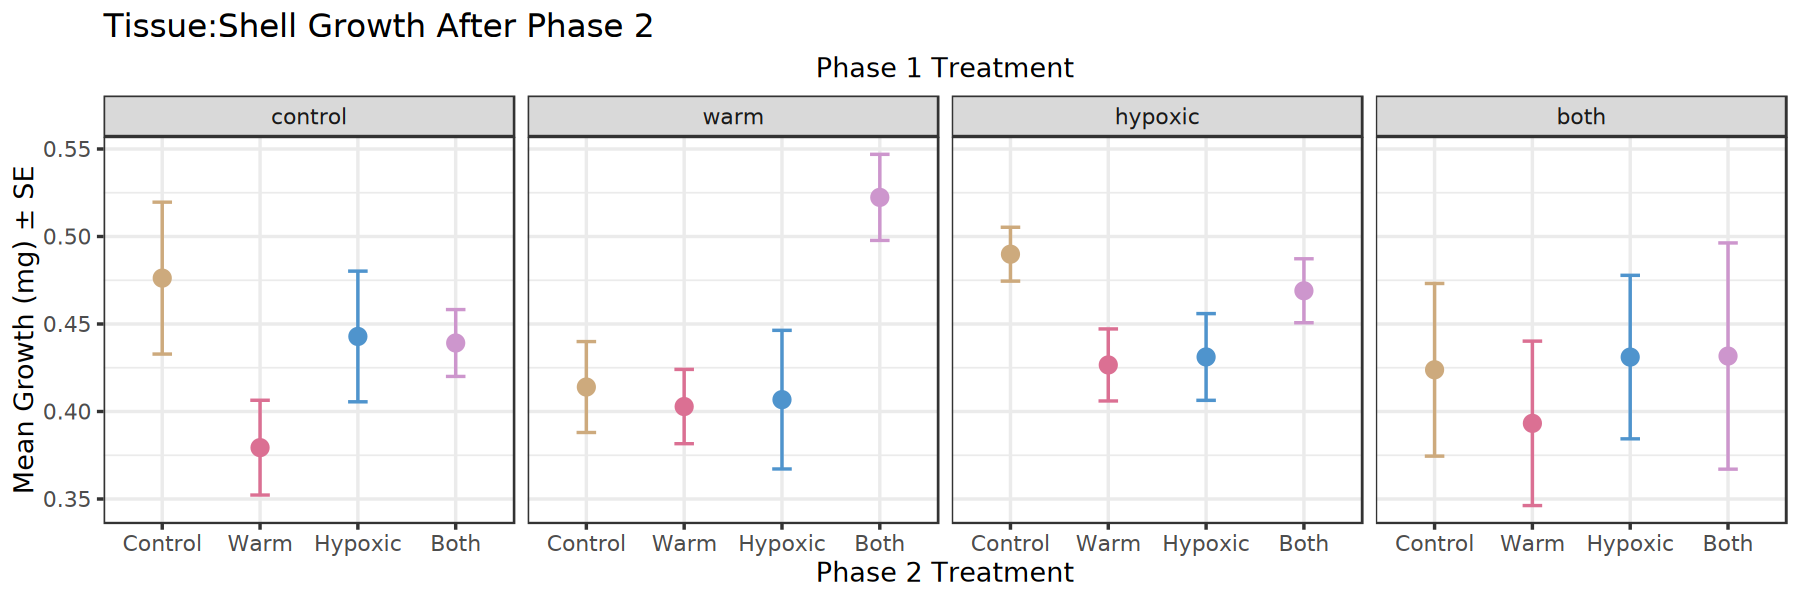

In [174]:
ratio16_plot <- ggplot(ratio16, aes(x = Phase2_treatment, y = mean_growth, color = Phase2_treatment)) +
# Plot means as points
geom_point(size = 4, position = position_dodge(0.9)) + 
 # Error bars for SD
geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
              width = 0.2, position = position_dodge(0.9)) +
#scale_y_continuous(position = "right") +   # move y-axis to right 
facet_wrap(~Phase1_treatment, nrow = 1) +
scale_color_manual(values = c("hypoxic" = "steelblue3", "warm" = "palevioletred", "control" = "burlywood3", "both" = "plum3")) +
scale_x_discrete(labels = stringr::str_to_title) +
guides(fill = 'none') +
labs(x = 'Phase 2 Treatment',
    y = 'Mean Growth (mg) ± SE',
    title = 'Tissue:Shell Growth After Phase 2',
    subtitle = 'Phase 1 Treatment') +
theme_bw(base_size = 16) +
theme(legend.position = "none",
      plot.subtitle = element_text(hjust = 0.5)
) 

ratio16_plot

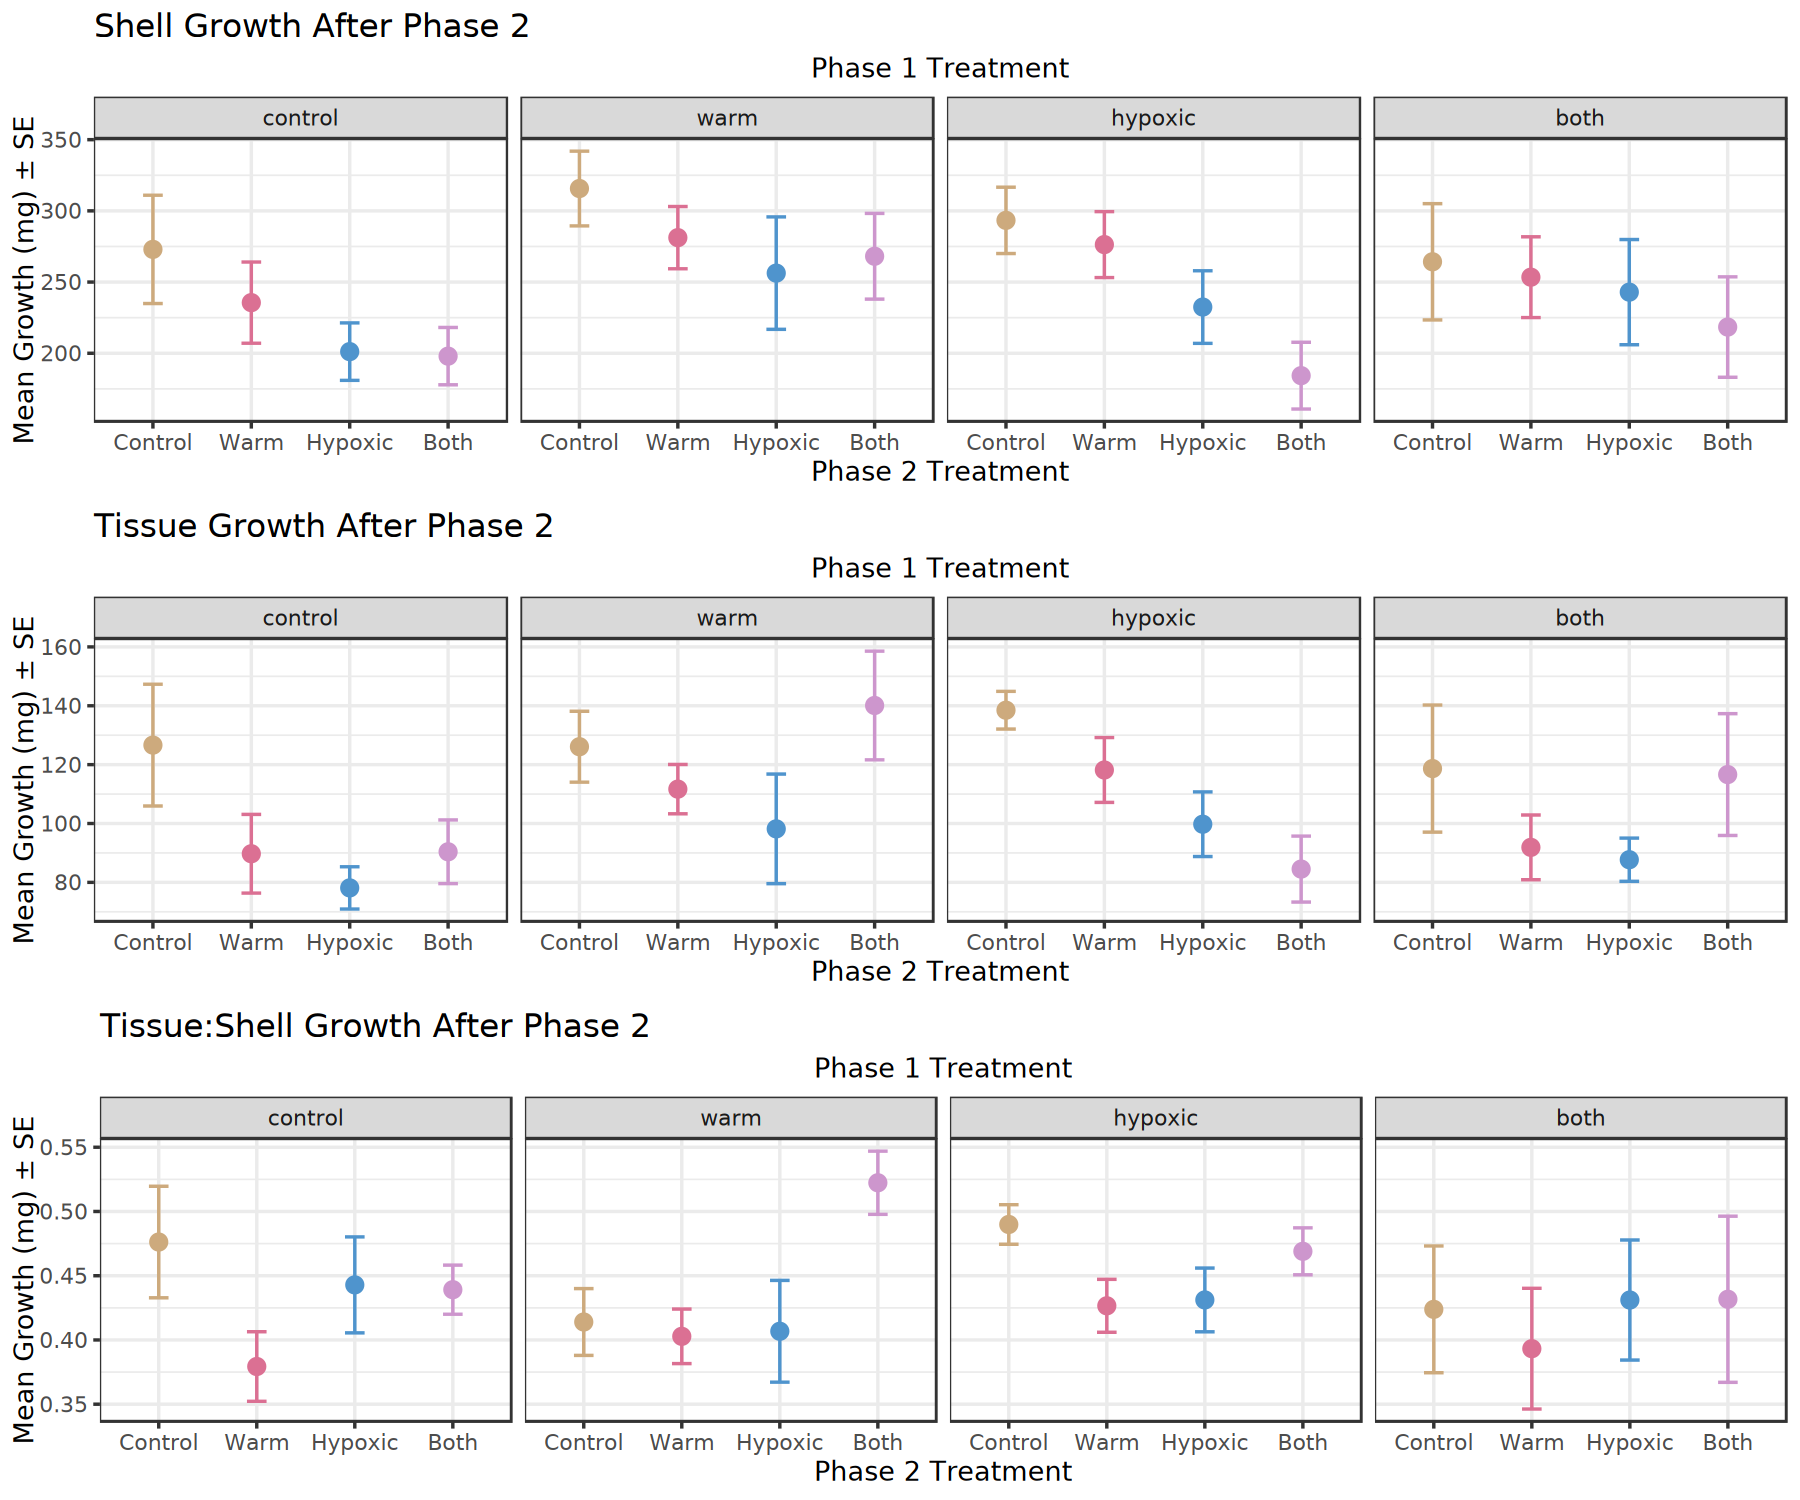

In [175]:
options(repr.plot.height = 12.5, repr.plot.width = 15) 

plot16 <- plot_grid(shell16_plot, tissue16_plot, ratio16_plot, nrow = 3)
plot16

In [176]:
ggsave(
  filename = '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/growth/plots/p2_trtmtCombo_growth.png', 
  plot = plot16, 
  width = 15,    
  height = 12.5,     
  units = "in", 
  dpi = 300         # High resolution for clarity
)

# Phase 1 oysters

as a note, these plots include ALL genetics oysters, not just the ones we sequenced. To see the same plots but only for those we sequenced for RNA-seq, see [module_GE.ipynb](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/phase1_v_phase1/wgcna/module_GE.ipynb).

## 1. load CSVs

In [129]:
p1.growth.df <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/metaData/growth_phase1_weights.csv')

p1.growth.df$Tag_num <- sprintf("%02d", p1.growth.df$Tag_num)
head(p1.growth.df)

,Sample_Name,Order_pre,Date_MMDDYYYY_pre,Year,Phase_1_treat,Phase_1_rep,Phase_2_treat,Phase_2_rep,Tag_color,Tag_num,⋯,Notes_post,Actual_shell_pre_mg,Actual_shell_post_mg,Actual_shell_growth_mg,Actual_tissue_pre_mg,Actual_tissue_post_mg,Actual_tissue_growth_mg,Ratio_tissue_shell_mg,Phase_1_temp,Phase_1_DO
,<chr>,<int>,<int>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
1,2024_Both01_Null_O1,98,5312024,2024,Both,1,null,null,O,01,⋯,NA,30.76476,73.04154,42.27678,24.33524,46.25846,21.92322,0.518564091,Warm,Hyp
2,2024_Both01_Null_O2,99,5312024,2024,Both,1,null,null,O,02,⋯,NA,41.05686,104.70954,63.65268,33.24314,75.59046,42.34732,0.665287306,Warm,Hyp
3,2024_Both01_Null_O3,100,5312024,2024,Both,1,null,null,O,03,⋯,NA,39.94848,117.53508,77.58660,33.05152,60.96492,27.91340,0.359770888,Warm,Hyp
4,2024_Both01_Null_O4,101,5312024,2024,Both,1,null,null,O,04,⋯,NA,66.39126,223.78122,157.38996,66.90874,215.11878,148.21004,0.941674043,Warm,Hyp
5,2024_Both01_Null_O5,102,5312024,2024,Both,1,null,null,O,05,⋯,NA,28.70634,9.23052,-19.47582,43.59366,3.56948,-40.02418,2.055070339,Warm,Hyp
6,2024_Both01_Null_O6,104,5312024,2024,Both,1,null,null,O,06,⋯,NA,60.37434,241.67364,181.29930,55.92566,173.42636,117.50070,0.64810344,Warm,Hyp


In [130]:
# creating sample name to match other dfs
p1.growth2 <- p1.growth.df %>% mutate(Sample = paste0(substr(Phase_1_treat, 1, 1), Phase_1_rep, "_Nu_", Tag_color, Tag_num))
head(p1.growth2)

,Sample_Name,Order_pre,Date_MMDDYYYY_pre,Year,Phase_1_treat,Phase_1_rep,Phase_2_treat,Phase_2_rep,Tag_color,Tag_num,⋯,Actual_shell_pre_mg,Actual_shell_post_mg,Actual_shell_growth_mg,Actual_tissue_pre_mg,Actual_tissue_post_mg,Actual_tissue_growth_mg,Ratio_tissue_shell_mg,Phase_1_temp,Phase_1_DO,Sample
,<chr>,<int>,<int>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
1,2024_Both01_Null_O1,98,5312024,2024,Both,1,null,null,O,01,⋯,30.76476,73.04154,42.27678,24.33524,46.25846,21.92322,0.518564091,Warm,Hyp,B1_Nu_O01
2,2024_Both01_Null_O2,99,5312024,2024,Both,1,null,null,O,02,⋯,41.05686,104.70954,63.65268,33.24314,75.59046,42.34732,0.665287306,Warm,Hyp,B1_Nu_O02
3,2024_Both01_Null_O3,100,5312024,2024,Both,1,null,null,O,03,⋯,39.94848,117.53508,77.58660,33.05152,60.96492,27.91340,0.359770888,Warm,Hyp,B1_Nu_O03
4,2024_Both01_Null_O4,101,5312024,2024,Both,1,null,null,O,04,⋯,66.39126,223.78122,157.38996,66.90874,215.11878,148.21004,0.941674043,Warm,Hyp,B1_Nu_O04
5,2024_Both01_Null_O5,102,5312024,2024,Both,1,null,null,O,05,⋯,28.70634,9.23052,-19.47582,43.59366,3.56948,-40.02418,2.055070339,Warm,Hyp,B1_Nu_O05
6,2024_Both01_Null_O6,104,5312024,2024,Both,1,null,null,O,06,⋯,60.37434,241.67364,181.29930,55.92566,173.42636,117.50070,0.64810344,Warm,Hyp,B1_Nu_O06


In [123]:
p1wgcna <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/wgcna/outputs/p1.wgcna_metadata.csv')
head(p1wgcna)

,X,Sample,Phase1_treatment,Phase1_temp,Phase1_DO,Module,Eigengene
,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
1,1,B1_Nu_O03,both,warm,hypoxic,MEturquoise,-0.27982387
2,2,B2_Nu_O12,both,warm,hypoxic,MEturquoise,0.26066812
3,3,B4_Nu_O32,both,warm,hypoxic,MEturquoise,0.13987997
4,4,B5_Nu_O36,both,warm,hypoxic,MEturquoise,-0.29840124
5,5,B6_Nu_O47,both,warm,hypoxic,MEturquoise,-0.25845679
6,6,C1_Nu_W01,control,ambient,normoxic,MEturquoise,0.07930803


pull only the samples that were sequenced and analyzed

In [125]:
p1.growth3 <- p1.growth2[p1.growth2$Sample %in% p1wgcna$Sample,]

dim(p1.growth3)
head(p1.growth3)

[1] 23 29

,Sample_Name,Order_pre,Date_MMDDYYYY_pre,Year,Phase_1_treat,Phase_1_rep,Phase_2_treat,Phase_2_rep,Tag_color,Tag_num,⋯,Actual_shell_pre_mg,Actual_shell_post_mg,Actual_shell_growth_mg,Actual_tissue_pre_mg,Actual_tissue_post_mg,Actual_tissue_growth_mg,Ratio_tissue_shell_mg,Phase_1_temp,Phase_1_DO,Sample
,<chr>,<int>,<int>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
3,2024_Both01_Null_O3,100,5312024,2024,Both,1,null,null,O,03,⋯,39.94848,117.53508,77.58660,33.05152,60.96492,27.91340,0.359770888,Warm,Hyp,B1_Nu_O03
10,2024_Both02_Null_O12,108,5312024,2024,Both,2,null,null,O,12,⋯,41.69022,192.11322,150.42300,39.40978,119.78678,80.37700,0.534339828,Warm,Hyp,B2_Nu_O12
31,2024_Both04_Null_O32,128,5312024,2024,Both,4,null,null,O,32,⋯,51.50730,196.54674,145.03944,66.19270,171.55326,105.36056,0.726426964,Warm,Hyp,B4_Nu_O32
35,2024_Both05_Null_O36,132,5312024,2024,Both,5,null,null,O,36,⋯,52.14066,84.91704,32.77638,39.95934,65.18296,25.22362,0.769566987,Warm,Hyp,B5_Nu_O36
46,2024_Both06_Null_O47,143,5312024,2024,Both,6,null,null,O,47,⋯,49.76556,167.57052,117.80496,41.13444,28.82948,-12.30496,-0.104451969,Warm,Hyp,B6_Nu_O47
49,2024_Cont01_Null_W1,146,5312024,2024,Cont,1,null,null,W,01,⋯,72.72486,305.16798,232.44312,61.97514,198.93202,136.95688,0.589205996,Ambient,Norm,C1_Nu_W01


In [127]:
unique(p1.growth3$Phase_1_treat)

[1] "Both" "Cont" "Hyp"  "Warm"

In [128]:
p1.growth <- p1.growth3

### set levels

In [131]:
# DO
p1.growth$Phase_1_DO <- factor(p1.growth$Phase_1_DO, 
                                        levels = c("Norm", "Hyp"))

# temp
p1.growth$Phase_1_temp <- factor(p1.growth$Phase_1_temp, 
                                        levels = c("Ambient", "Warm"))

# treatment interaction
p1.growth$Phase_1_treat <- factor(p1.growth$Phase_1_treat,
                                levels = c('Cont', 'Warm', 'Hyp', 'Both'))

In [132]:
p1.shell <- p1.growth %>%
select(Sample_Name, Phase_1_treat, Phase_1_DO, Phase_1_temp, Actual_shell_growth_mg)
head(p1.shell)

,Sample_Name,Phase_1_treat,Phase_1_DO,Phase_1_temp,Actual_shell_growth_mg
,<chr>,<fct>,<fct>,<fct>,<dbl>
3,2024_Both01_Null_O3,Both,Hyp,Warm,77.58660
10,2024_Both02_Null_O12,Both,Hyp,Warm,150.42300
31,2024_Both04_Null_O32,Both,Hyp,Warm,145.03944
35,2024_Both05_Null_O36,Both,Hyp,Warm,32.77638
46,2024_Both06_Null_O47,Both,Hyp,Warm,117.80496
49,2024_Cont01_Null_W1,Cont,Norm,Ambient,232.44312


In [133]:
p1.tissue <- p1.growth %>%
select(Sample_Name, Phase_1_treat, Phase_1_DO, Phase_1_temp, Actual_tissue_growth_mg)
head(p1.tissue)

,Sample_Name,Phase_1_treat,Phase_1_DO,Phase_1_temp,Actual_tissue_growth_mg
,<chr>,<fct>,<fct>,<fct>,<dbl>
3,2024_Both01_Null_O3,Both,Hyp,Warm,27.91340
10,2024_Both02_Null_O12,Both,Hyp,Warm,80.37700
31,2024_Both04_Null_O32,Both,Hyp,Warm,105.36056
35,2024_Both05_Null_O36,Both,Hyp,Warm,25.22362
46,2024_Both06_Null_O47,Both,Hyp,Warm,-12.30496
49,2024_Cont01_Null_W1,Cont,Norm,Ambient,136.95688


## 2. plot

### Shell Growth

#### DO only

In [134]:
# get mean and SE for phase 1 DO
DOstats <- p1.shell %>%
  dplyr::group_by(Phase_1_DO) %>%
  mutate(
    mean_growth = mean(Actual_shell_growth_mg, na.rm = TRUE),
    se_growth = std.error(Actual_shell_growth_mg, na.rm = TRUE)) %>%
distinct(Phase_1_DO, .keep_all = TRUE)

DOstats

Sample_Name,Phase_1_treat,Phase_1_DO,Phase_1_temp,Actual_shell_growth_mg,mean_growth,se_growth
<chr>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>
2024_Both01_Null_O3,Both,Hyp,Warm,77.5866,99.71102,13.24609
2024_Cont01_Null_W1,Cont,Norm,Ambient,232.4431,140.93579,13.70864


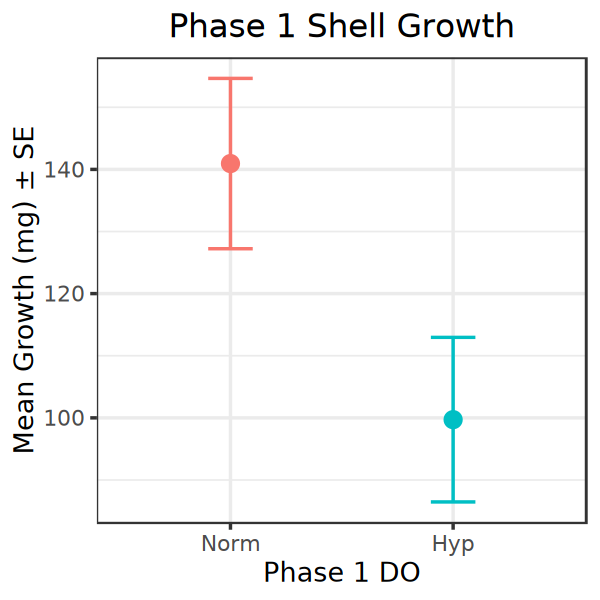

In [135]:
options(repr.plot.height = 5, repr.plot.width = 5)

ggplot(DOstats, aes(x = Phase_1_DO, y = mean_growth, color = Phase_1_DO)) +
geom_point(size = 4, position = position_dodge(0.0)) +
geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
              width = 0.2, position = position_dodge(0.9)) +
guides(fill = 'none') +
labs(x = 'Phase 1 DO',
    y = 'Mean Growth (mg) ± SE',
    title = 'Phase 1 Shell Growth') +
theme_bw(base_size = 16) +
theme(legend.position = "none",
      plot.title = element_text(hjust = 0.5)
) 

#### Temp only

In [136]:
# get mean and SE for phase 1 DO
tempstats <- p1.shell %>%
  group_by(Phase_1_temp) %>%
  mutate(
    mean_growth = mean(Actual_shell_growth_mg, na.rm = TRUE),
    se_growth = std.error(Actual_shell_growth_mg, na.rm = TRUE)) %>%
distinct(Phase_1_temp, .keep_all = TRUE)

tempstats

Sample_Name,Phase_1_treat,Phase_1_DO,Phase_1_temp,Actual_shell_growth_mg,mean_growth,se_growth
<chr>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>
2024_Both01_Null_O3,Both,Hyp,Warm,77.5866,126.8879,15.13647
2024_Cont01_Null_W1,Cont,Norm,Ambient,232.4431,116.0236,14.55933


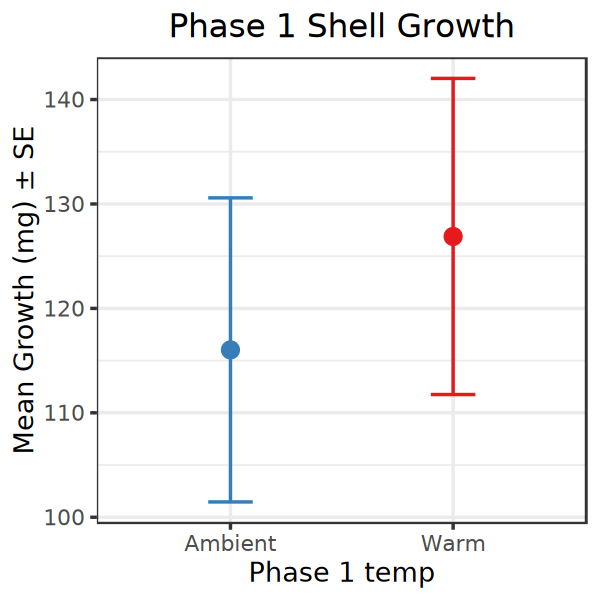

In [137]:
options(repr.plot.height = 5, repr.plot.width = 5)

ggplot(tempstats, aes(x = Phase_1_temp, y = mean_growth, color = Phase_1_temp)) +
geom_point(size = 4, position = position_dodge(0.0)) +
geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
              width = 0.2, position = position_dodge(0.9)) +
guides(fill = 'none') +
labs(x = 'Phase 1 temp',
    y = 'Mean Growth (mg) ± SE',
    title = 'Phase 1 Shell Growth') +
scale_color_brewer(palette = 'Set1', direction = -1) +
theme_bw(base_size = 16) +
theme(legend.position = "none",
      plot.title = element_text(hjust = 0.5)
) 

#### Interaction

#### DO only

In [138]:
# get mean and SE for phase 1 DO
interstats <- p1.shell %>%
  group_by(Phase_1_treat) %>%
  mutate(
    mean_growth = mean(Actual_shell_growth_mg, na.rm = TRUE),
    se_growth = std.error(Actual_shell_growth_mg, na.rm = TRUE)) %>%
distinct(Phase_1_treat, .keep_all = TRUE)

interstats

Sample_Name,Phase_1_treat,Phase_1_DO,Phase_1_temp,Actual_shell_growth_mg,mean_growth,se_growth
<chr>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>
2024_Both01_Null_O3,Both,Hyp,Warm,77.58660,104.7261,22.13339
2024_Cont01_Null_W1,Cont,Norm,Ambient,232.44312,136.5155,21.34587
2024_Hyp01_Null_B8,Hyp,Hyp,Ambient,60.16920,95.5318,17.58048
2024_Warm01_Null_G2,Warm,Norm,Warm,60.32754,145.3561,19.06346


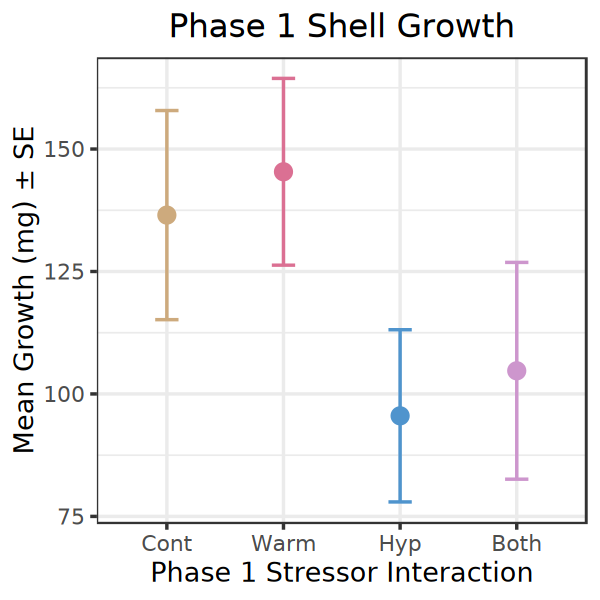

In [139]:
p1.shell <- ggplot(interstats, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
geom_point(size = 4, position = position_dodge(0.0)) +
geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
              width = 0.2, position = position_dodge(0.9)) +
guides(fill = 'none') +
labs(x = 'Phase 1 Stressor Interaction',
    y = 'Mean Growth (mg) ± SE',
    title = 'Phase 1 Shell Growth') +
scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred", "Cont" = "burlywood3", "Both" = "plum3")) +
theme_bw(base_size = 16) +
theme(legend.position = "none",
      plot.title = element_text(hjust = 0.5)
) 

p1.shell

doesn't appear to be a difference between warm and hypoxia, but a large difference between control and both

### Tissue Growth

#### DO only

In [140]:
# get mean and SE for phase 1 DO
DOstats.t <- p1.tissue %>%
  group_by(Phase_1_DO) %>%
  mutate(
    mean_growth = mean(Actual_tissue_growth_mg, na.rm = TRUE),
    se_growth = std.error(Actual_tissue_growth_mg, na.rm = TRUE)) %>%
distinct(Phase_1_DO, .keep_all = TRUE)

DOstats.t

Sample_Name,Phase_1_treat,Phase_1_DO,Phase_1_temp,Actual_tissue_growth_mg,mean_growth,se_growth
<chr>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>
2024_Both01_Null_O3,Both,Hyp,Warm,27.9134,58.85262,14.128633
2024_Cont01_Null_W1,Cont,Norm,Ambient,136.9569,86.85587,8.905528


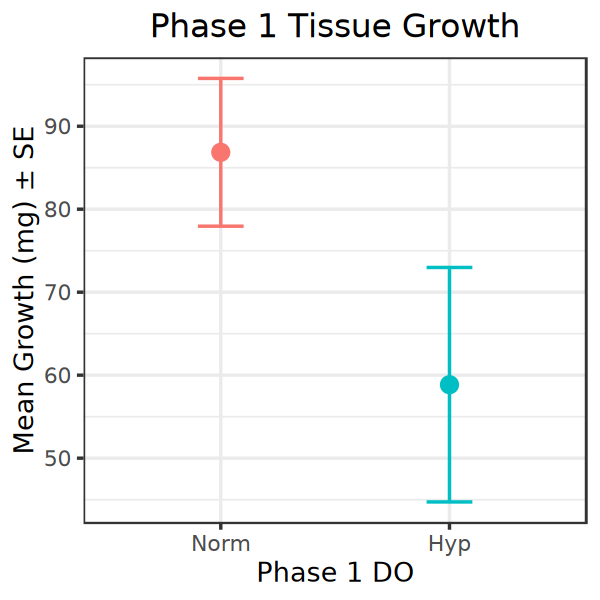

In [141]:
ggplot(DOstats.t, aes(x = Phase_1_DO, y = mean_growth, color = Phase_1_DO)) +
geom_point(size = 4, position = position_dodge(0.0)) +
geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
              width = 0.2, position = position_dodge(0.9)) +
guides(fill = 'none') +
labs(x = 'Phase 1 DO',
    y = 'Mean Growth (mg) ± SE',
    title = 'Phase 1 Tissue Growth') +
theme_bw(base_size = 16) +
theme(legend.position = "none",
      plot.title = element_text(hjust = 0.5)
) 

#### Temp only

In [142]:
# get mean and SE for phase 1 DO
tempstats.t <- p1.tissue %>%
  group_by(Phase_1_temp) %>%
  mutate(
    mean_growth = mean(Actual_tissue_growth_mg, na.rm = TRUE),
    se_growth = std.error(Actual_tissue_growth_mg, na.rm = TRUE)) %>%
distinct(Phase_1_temp, .keep_all = TRUE)

tempstats.t

Sample_Name,Phase_1_treat,Phase_1_DO,Phase_1_temp,Actual_tissue_growth_mg,mean_growth,se_growth
<chr>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>
2024_Both01_Null_O3,Both,Hyp,Warm,27.9134,70.42117,12.53134
2024_Cont01_Null_W1,Cont,Norm,Ambient,136.9569,76.25137,12.14133


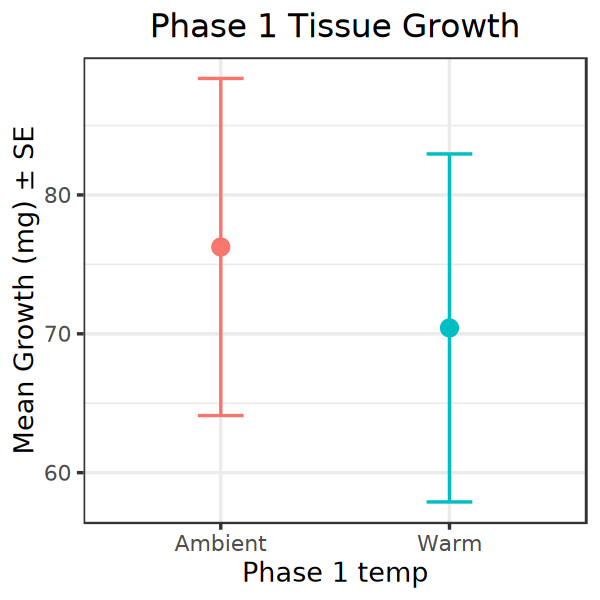

In [143]:
ggplot(tempstats.t, aes(x = Phase_1_temp, y = mean_growth, color = Phase_1_temp)) +
geom_point(size = 4, position = position_dodge(0.0)) +
geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
              width = 0.2, position = position_dodge(0.9)) +
guides(fill = 'none') +
labs(x = 'Phase 1 temp',
    y = 'Mean Growth (mg) ± SE',
    title = 'Phase 1 Tissue Growth') +
theme_bw(base_size = 16) +
theme(legend.position = "none",
      plot.title = element_text(hjust = 0.5)
) 

#### Interaction

In [144]:
# get mean and SE for phase 1 DO
interstats.t <- p1.tissue %>%
  group_by(Phase_1_treat) %>%
  mutate(
    mean_growth = mean(Actual_tissue_growth_mg, na.rm = TRUE),
    se_growth = std.error(Actual_tissue_growth_mg, na.rm = TRUE)) %>%
distinct(Phase_1_treat, .keep_all = TRUE)

interstats.t

Sample_Name,Phase_1_treat,Phase_1_DO,Phase_1_temp,Actual_tissue_growth_mg,mean_growth,se_growth
<chr>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>
2024_Both01_Null_O3,Both,Hyp,Warm,27.91340,45.31392,21.049171
2024_Cont01_Null_W1,Cont,Norm,Ambient,136.95688,82.36786,15.909110
2024_Hyp01_Null_B8,Hyp,Hyp,Ambient,47.03080,70.13487,19.507641
2024_Warm01_Null_G2,Warm,Norm,Warm,46.77246,91.34388,9.370189


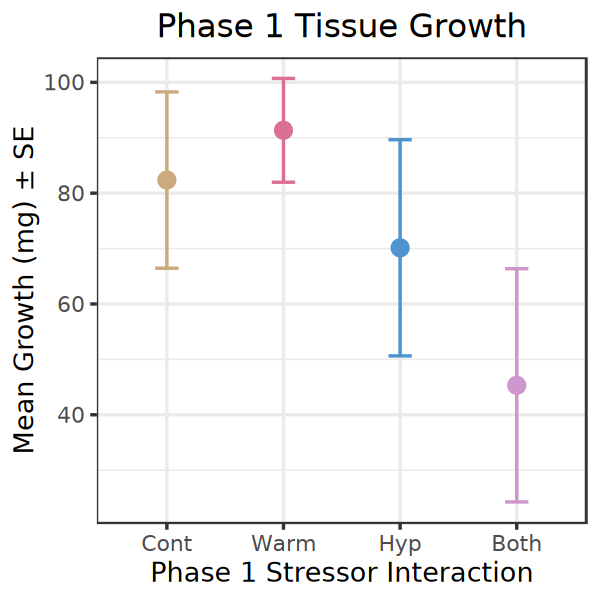

In [145]:
p1.t <- ggplot(interstats.t, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
geom_point(size = 4, position = position_dodge(0.0)) +
geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
              width = 0.2, position = position_dodge(0.9)) +
guides(fill = 'none') +
labs(x = 'Phase 1 Stressor Interaction',
    y = 'Mean Growth (mg) ± SE',
    title = 'Phase 1 Tissue Growth') +
scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred", "Cont" = "burlywood3", "Both" = "plum3")) +
theme_bw(base_size = 16) +
theme(legend.position = "none",
      plot.title = element_text(hjust = 0.5)
) 

p1.t

### Ratio T:S

In [146]:
p1.ts <- p1.growth %>%
select(Sample_Name, Phase_1_treat, Phase_1_DO, Phase_1_temp, Ratio_tissue_shell_mg) %>%
filter(Ratio_tissue_shell_mg > 0)

p1.ts$Ratio_tissue_shell_mg <- as.numeric(p1.ts$ Ratio_tissue_shell_mg)
head(p1.ts)

,Sample_Name,Phase_1_treat,Phase_1_DO,Phase_1_temp,Ratio_tissue_shell_mg
,<chr>,<fct>,<fct>,<fct>,<dbl>
1,2024_Both01_Null_O3,Both,Hyp,Warm,0.3597709
2,2024_Both02_Null_O12,Both,Hyp,Warm,0.5343398
3,2024_Both04_Null_O32,Both,Hyp,Warm,0.7264270
4,2024_Both05_Null_O36,Both,Hyp,Warm,0.7695670
5,2024_Cont01_Null_W1,Cont,Norm,Ambient,0.5892060
6,2024_Cont01_Null_W5,Cont,Norm,Ambient,0.7360673


#### DO only

In [147]:
# get mean and SE for phase 1 DO
DOstats.t <- p1.ts %>%
  group_by(Phase_1_DO) %>%
  mutate(
    mean_growth = mean(Ratio_tissue_shell_mg, na.rm = TRUE),
    se_growth = std.error(Ratio_tissue_shell_mg, na.rm = TRUE)) %>%
distinct(Phase_1_DO, .keep_all = TRUE)

DOstats.t

Sample_Name,Phase_1_treat,Phase_1_DO,Phase_1_temp,Ratio_tissue_shell_mg,mean_growth,se_growth
<chr>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>
2024_Both01_Null_O3,Both,Hyp,Warm,0.3597709,0.6538053,0.06950166
2024_Cont01_Null_W1,Cont,Norm,Ambient,0.5892060,0.6204661,0.03752504


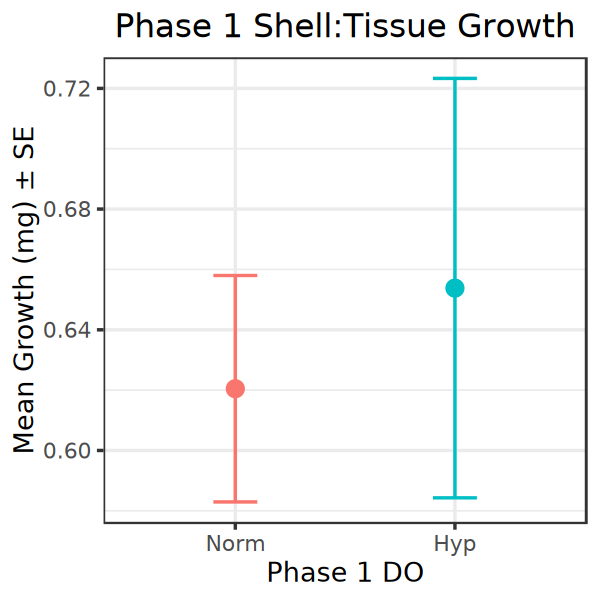

In [148]:
ggplot(DOstats.t, aes(x = Phase_1_DO, y = mean_growth, color = Phase_1_DO)) +
geom_point(size = 4, position = position_dodge(0.0)) +
geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
              width = 0.2, position = position_dodge(0.9)) +
guides(fill = 'none') +
labs(x = 'Phase 1 DO',
    y = 'Mean Growth (mg) ± SE',
    title = 'Phase 1 Shell:Tissue Growth') +
theme_bw(base_size = 16) +
theme(legend.position = "none",
      plot.title = element_text(hjust = 0.5)
) 

#### Temp only

In [149]:
# get mean and SE for phase 1 DO
tempstats.t <- p1.ts %>%
  group_by(Phase_1_temp) %>%
  mutate(
    mean_growth = mean(Ratio_tissue_shell_mg, na.rm = TRUE),
    se_growth = std.error(Ratio_tissue_shell_mg, na.rm = TRUE)) %>%
distinct(Phase_1_temp, .keep_all = TRUE)

tempstats.t

Sample_Name,Phase_1_treat,Phase_1_DO,Phase_1_temp,Ratio_tissue_shell_mg,mean_growth,se_growth
<chr>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>
2024_Both01_Null_O3,Both,Hyp,Warm,0.3597709,0.6316106,0.04527407
2024_Cont01_Null_W1,Cont,Norm,Ambient,0.5892060,0.6389617,0.05786003


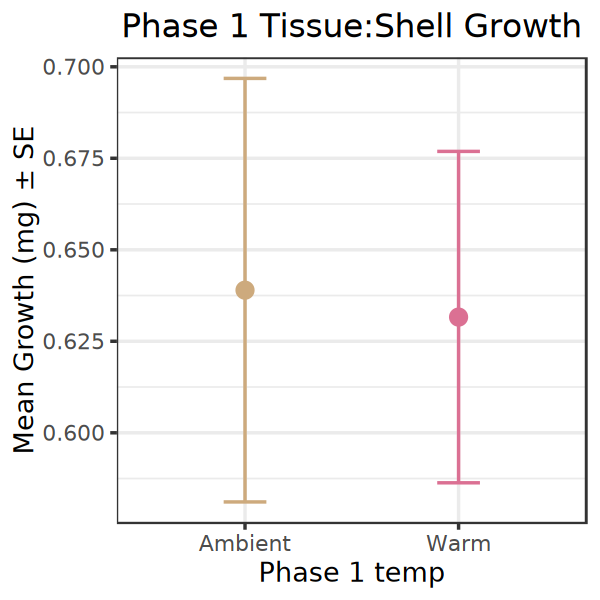

In [150]:
ggplot(tempstats.t, aes(x = Phase_1_temp, y = mean_growth, color = Phase_1_temp)) +
geom_point(size = 4, position = position_dodge(0.0)) +
geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
              width = 0.2, position = position_dodge(0.9)) +
guides(fill = 'none') +
labs(x = 'Phase 1 temp',
    y = 'Mean Growth (mg) ± SE',
    title = 'Phase 1 Tissue:Shell Growth') +
scale_color_manual(values = c("Warm" = "palevioletred", "Ambient" = "burlywood3")) +

theme_bw(base_size = 16) +
theme(legend.position = "none",
      plot.title = element_text(hjust = 0.5)
) 

#### Interaction

In [151]:
# get mean and SE for phase 1 DO
interstats.t <- p1.ts %>%
  group_by(Phase_1_treat) %>%
  mutate(
    mean_growth = mean(Ratio_tissue_shell_mg, na.rm = TRUE),
    se_growth = std.error(Ratio_tissue_shell_mg, na.rm = TRUE)) %>%
distinct(Phase_1_treat, .keep_all = TRUE)

interstats.t

Sample_Name,Phase_1_treat,Phase_1_DO,Phase_1_temp,Ratio_tissue_shell_mg,mean_growth,se_growth
<chr>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>
2024_Both01_Null_O3,Both,Hyp,Warm,0.3597709,0.5975262,0.09431046
2024_Cont01_Null_W1,Cont,Norm,Ambient,0.5892060,0.5865987,0.05834116
2024_Hyp01_Null_B8,Hyp,Hyp,Ambient,0.7816424,0.6913248,0.10114248
2024_Warm01_Null_G2,Warm,Norm,Warm,0.7753086,0.6543335,0.04830397


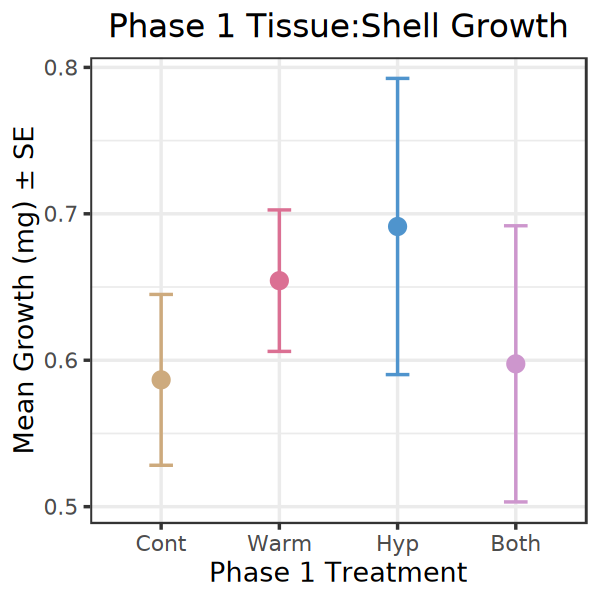

In [152]:
p1.ts <- ggplot(interstats.t, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
geom_point(size = 4, position = position_dodge(0.0)) +
geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
              width = 0.2, position = position_dodge(0.9)) +
guides(fill = 'none') +
labs(x = 'Phase 1 Treatment',
    y = 'Mean Growth (mg) ± SE',
    title = 'Phase 1 Tissue:Shell Growth') +
scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred", "Cont" = "burlywood3", "Both" = "plum3")) +
theme_bw(base_size = 16) +
theme(legend.position = "none",
      plot.title = element_text(hjust = 0.5)
) 

p1.ts

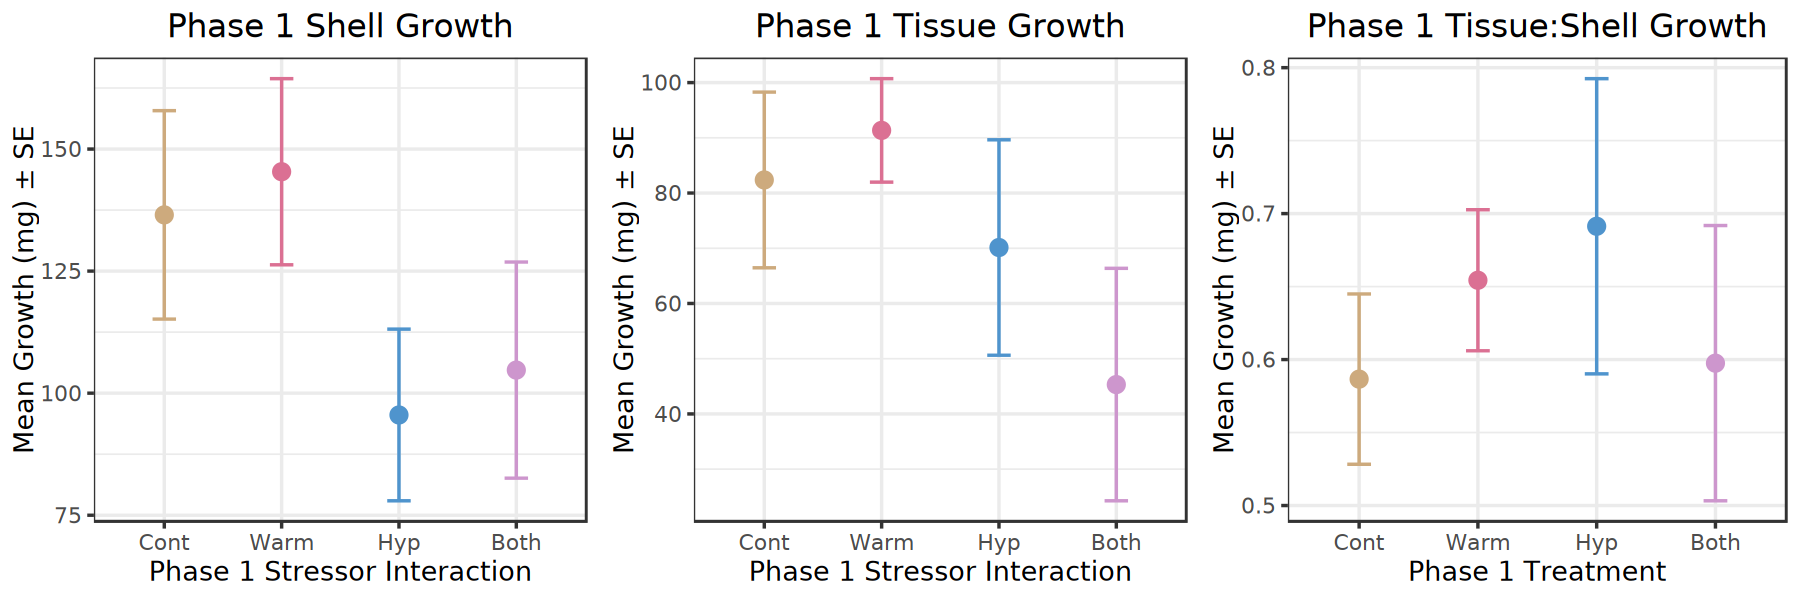

In [153]:
options(repr.plot.height = 5, repr.plot.width = 15)

plot1 <- plot_grid(p1.shell, p1.t, p1.ts, nrow = 1)
plot1

In [154]:
ggsave(
  filename = '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/growth/plots/phase1oys_growth.png', 
  plot = plot1, 
  width = 15,    
  height = 5,     
  units = "in", 
  dpi = 300         # High resolution for clarity
)

### violin plots

In [155]:
head(p1.growth)

,Sample_Name,Order_pre,Date_MMDDYYYY_pre,Year,Phase_1_treat,Phase_1_rep,Phase_2_treat,Phase_2_rep,Tag_color,Tag_num,⋯,Actual_shell_pre_mg,Actual_shell_post_mg,Actual_shell_growth_mg,Actual_tissue_pre_mg,Actual_tissue_post_mg,Actual_tissue_growth_mg,Ratio_tissue_shell_mg,Phase_1_temp,Phase_1_DO,Sample
,<chr>,<int>,<int>,<int>,<fct>,<int>,<chr>,<chr>,<chr>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<fct>,<fct>,<chr>
3,2024_Both01_Null_O3,100,5312024,2024,Both,1,null,null,O,03,⋯,39.94848,117.53508,77.58660,33.05152,60.96492,27.91340,0.359770888,Warm,Hyp,B1_Nu_O03
10,2024_Both02_Null_O12,108,5312024,2024,Both,2,null,null,O,12,⋯,41.69022,192.11322,150.42300,39.40978,119.78678,80.37700,0.534339828,Warm,Hyp,B2_Nu_O12
31,2024_Both04_Null_O32,128,5312024,2024,Both,4,null,null,O,32,⋯,51.50730,196.54674,145.03944,66.19270,171.55326,105.36056,0.726426964,Warm,Hyp,B4_Nu_O32
35,2024_Both05_Null_O36,132,5312024,2024,Both,5,null,null,O,36,⋯,52.14066,84.91704,32.77638,39.95934,65.18296,25.22362,0.769566987,Warm,Hyp,B5_Nu_O36
46,2024_Both06_Null_O47,143,5312024,2024,Both,6,null,null,O,47,⋯,49.76556,167.57052,117.80496,41.13444,28.82948,-12.30496,-0.104451969,Warm,Hyp,B6_Nu_O47
49,2024_Cont01_Null_W1,146,5312024,2024,Cont,1,null,null,W,01,⋯,72.72486,305.16798,232.44312,61.97514,198.93202,136.95688,0.589205996,Ambient,Norm,C1_Nu_W01


In [156]:
# change to numeric instead of character
p1.growth$Ratio_tissue_shell_mg <- as.numeric(p1.growth$Ratio_tissue_shell_mg)

p1.growth_long <- p1.growth %>% 
select(Sample_Name, Phase_1_treat, 'Shell Growth' = Actual_shell_growth_mg, 'Tissue Growth' = Actual_tissue_growth_mg) %>%
pivot_longer(cols = -c(Sample_Name, Phase_1_treat),
             names_to = 'Growth_parameter',
             values_to = 'Growth_mg')

head(p1.growth_long)

Sample_Name,Phase_1_treat,Growth_parameter,Growth_mg
<chr>,<fct>,<chr>,<dbl>
2024_Both01_Null_O3,Both,Shell Growth,77.5866
2024_Both01_Null_O3,Both,Tissue Growth,27.9134
2024_Both02_Null_O12,Both,Shell Growth,150.4230
2024_Both02_Null_O12,Both,Tissue Growth,80.3770
2024_Both04_Null_O32,Both,Shell Growth,145.0394
2024_Both04_Null_O32,Both,Tissue Growth,105.3606


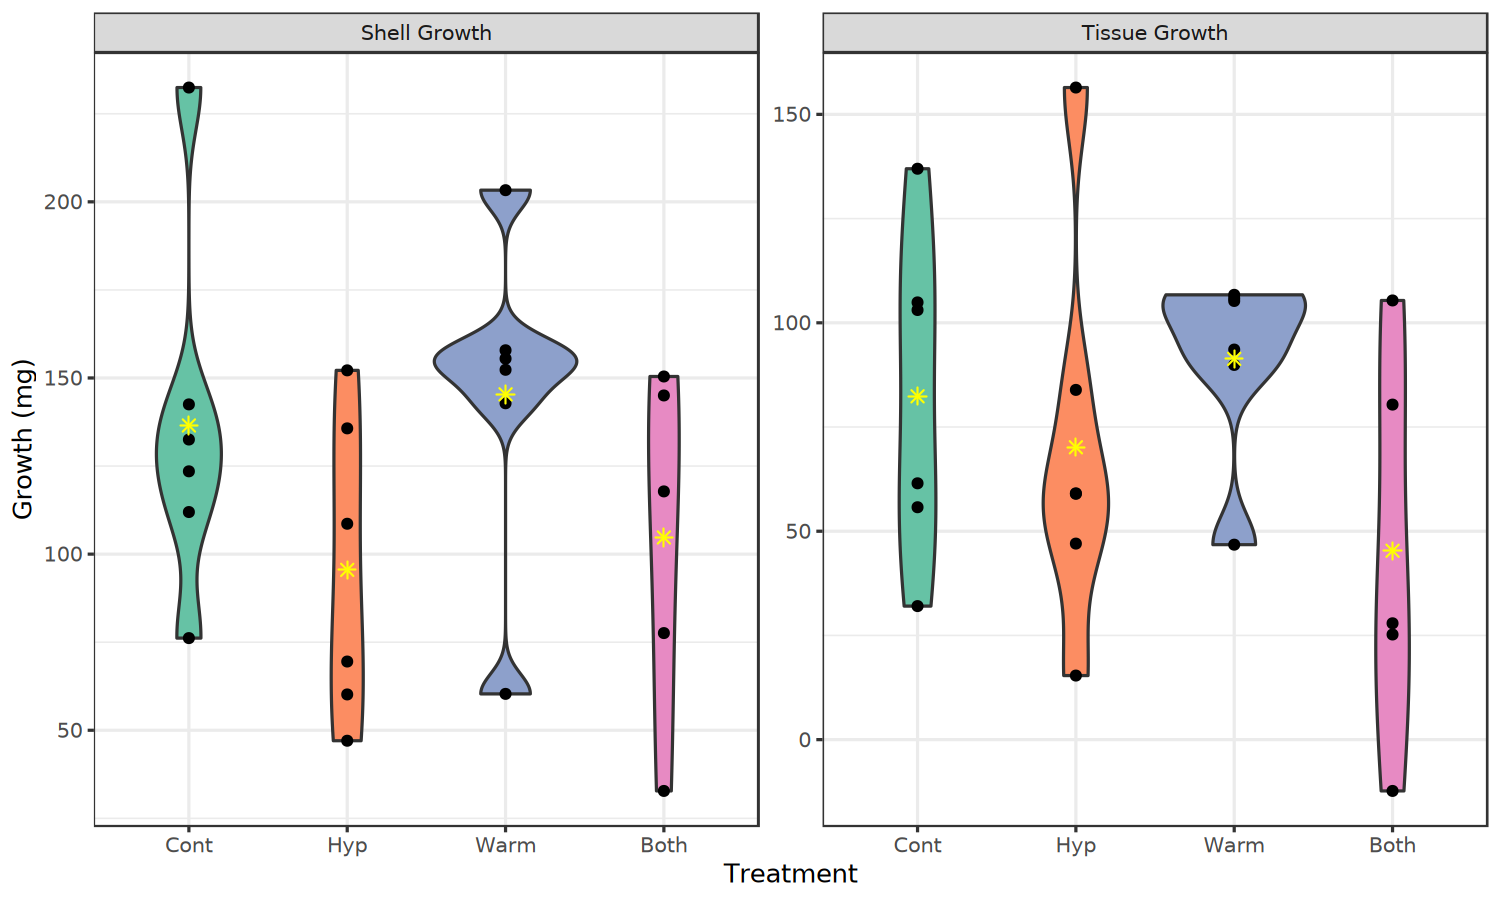

In [157]:
options(repr.plot.width = 12.5, repr.plot.height = 7.5)

p1.growth_long$Phase_1_treat <- fct_relevel(p1.growth_long$Phase_1_treat, "Warm", after = 2)

ggplot(p1.growth_long, aes(x = Phase_1_treat, y = Growth_mg, fill = Phase_1_treat)) +
geom_violin() +
geom_point() + 
# add point for mean
stat_summary(
    fun = "mean", 
    geom = "point", 
    shape = 8,      # asterick shape
    size = 3,        # Size of the point
    color = "yellow"  # Outline color
  ) +
scale_fill_brewer(palette = 'Set2') +
facet_wrap(~Growth_parameter, scales = 'free_y') +
guides(fill = 'none') +
theme_bw(base_size = 15) +
labs(x = 'Treatment',
     y = 'Growth (mg)')